# Análisis Estadístico Exhaustivo y Reporte de Resultados: Teclado Matemático Virtual vs. Pizarra Digital Manuscrita en Mateo Tutor

**Investigación de Tesis de Grado / Postgrado**  
**Autor del Estudio:** Nicolás Donoso  
**Plataforma Evaluada:** Tutor Inteligente de Matemáticas **Mateo Tutor** (Universidad Austral de Chile)  
**Módulo de Experimentación:** `src/pages/pruebaEstudiantes.tsx`  
**Datasets Analizados:**
1. `data_estudio_nicolasdonoso.xlsx` ($N = 14$ estudiantes, $84$ ensayos experimentales de telemetría y NASA-TLX).
2. `Encuesta_ Uso de Tablets en Matemáticas (Respuestas).xlsx` ($N = 14$ estudiantes, Caracterización de Perfil Inicial y Experiencia Previa).
3. `Encuesta Final_ Evaluación del Sistema de Ecuaciones (Respuestas).xlsx` ($N = 14$ estudiantes, Evaluación Cualitativa y Preferencia Post-Test).

---

### Índice General del Documento

1. **[1. Introducción, Justificación Teórica e Hipótesis de Investigación](#1-introducción-justificación-teórica-e-hipótesis-de-investigación)**
   - 1.1 Contexto y Problema de Interacción Humano-Computador (HCI)
   - 1.2 Hipótesis Experimentales Formales ($H_1, H_2, H_3$)
   - 1.3 Definición Operacional de Variables del Estudio
2. **[2. Metodología Experimental, Control de Sesgos y Caracterización de la Muestra (Pre-Encuesta)](#2-metodología-experimental-control-de-sesgos-y-caracterización-de-la-muestra-pre-encuesta)**
   - 2.1 Inicialización del Entorno Científico y Estilos CSS
   - 2.2 Ingesta de Datos Experimentales y Control de Balanceo Intra-Sujeto (Tablas 2.1 y 2.2)
   - 2.3 Caracterización del Perfil de Entrada y Experiencia Previa con Tablets (Tablas 2.3 y 2.4 - Pre-Encuesta)
   - 2.4 Análisis Metodológico de la Muestra y Control de Sesgos
3. **[3. Estadísticas Descriptivas Comparativas](#3-estadísticas-descriptivas-comparativas)**
   - 3.1 Estadísticas Descriptivas Globales Comparativas (Tabla 3.1)
   - 3.2 Estadísticas Descriptivas Desagregadas por Nivel de Complejidad (Tabla 3.2)
4. **[4. Inferencia Estadística, Contrastes Pareados y Matrices Paso a Paso](#4-inferencia-estadística-contrastes-pareados-y-matrices-paso-a-paso)**
   - 4.1 Protocolo Metodológico y Regla de Decisión (Normalidad Shapiro-Wilk)
   - 4.2 Contrastes de Hipótesis Pareados Globales (Tabla 4.1)
   - 4.3 Contrastes de Hipótesis Pareados por Complejidad (Tabla 4.2)
   - 4.4 Matrices de Desglose Paso a Paso Usuario por Usuario ($N=14$) (Tablas 4.4.1 a 4.4.5)
5. **[5. Visualizaciones y Análisis Gráfico Comparativo](#5-visualizaciones-y-análisis-gráfico-comparativo)**
   - 5.1 Distribución y Dispersión: Boxplots con Stripplots (Gráfico 5.1)
   - 5.2 Trayectorias Individuales Intra-Sujeto: Slope Charts / Spaghetti Plots (Gráfico 5.2)
   - 5.3 Perfil Multidimensional NASA-TLX: Radar Chart (Gráfico 5.3)
   - 5.4 Efecto de Interacción Modalidad × Complejidad: Interaction Plots (Gráfico 5.4)
   - 5.5 Desglose Anatómico por Ejercicio Individual ($E1$ a $E6$) (Gráfico 5.5)
6. **[6. Evaluación Cualitativa Post-Estudio, Discusión Teórica y Conclusiones (Post-Encuesta)](#6-evaluación-cualitativa-post-estudio-discusión-teórica-y-conclusiones-post-encuesta)**
   - 6.1 Distribución Cuantitativa de Preferencias Subjetivas Post-Test (Tabla 6.1 y Gráfico 6.1)
   - 6.2 Matriz Cualitativa de Respuestas y Justificaciones de los Participantes (Tabla 6.2)
   - 6.3 Triangulación Metodológica e Interpretación con Teoría de Carga Cognitiva (Sweller)
   - 6.4 Respuestas a las Preguntas de Investigación de la Tesis
   - 6.5 Recomendaciones de Diseño de Interfaz y Arquitectura Adaptativa para Mateo Tutor
   - 6.6 Conclusión Final de la Tesis


---

## 1. Introducción, Justificación Teórica e Hipótesis de Investigación

### 1.1 Contexto y Problema de Interacción Humano-Computador (HCI)
La educación matemática asistida por computador enfrenta una barrera fundamental conocida como la **brecha de representación de entrada**. A diferencia del texto estándar, el lenguaje matemático posee una **sintaxis bidimensional espacial** (fracciones con numeradores y denominadores apilados, exponentes, subíndices, raíces cuadradas y delimitadores agrupados). 

Los entornos digitales tradicionales obligan al estudiante a transcribir estas estructuras mediante:
1. **Sintaxis lineal abstracta (LaTeX / ASCII):** Requiere memorizar comandos como `\frac{a}{b}` o `\sqrt{x}`.
2. **Teclados Matemáticos Virtuales (MathQuill / Botones):** Aunque facilitan la visualización gráfica inmediata, obligan al usuario a buscar botones en paneles flotantes y navegar un cursor dentro de cajas anidadas usando teclas direccionales o toques en pantalla.

Para resolver este conflicto en **Mateo Tutor**, se implementó y evaluó experimentalmente una **Pizarra Digital Manuscrita con OCR** (`MathPixBoard`), que permite al estudiante escribir a mano alzada con lápiz o dedo directamente en el lienzo digital, mientras una red neuronal de reconocimiento óptico de caracteres (API MathPix) interpreta los trazos y genera el código LaTeX de forma transparente.

---

### 1.2 Hipótesis Experimentales Formales
* **Hipótesis de Eficiencia ($H_1$):** La Pizarra Manuscrita reduce significativamente el tiempo de ingreso (en segundos) en expresiones con estructuras bidimensionales (fracciones y raíces) respecto al Teclado Virtual.
* **Hipótesis de Carga Cognitiva ($H_2$):** La Pizarra Manuscrita reduce la demanda mental, el esfuerzo percibido y la frustración subjetiva (medidas con NASA-TLX) al eliminar la fricción de navegación espacial del teclado.
* **Hipótesis de Interacción Modalidad $\times$ Complejidad ($H_3$):** Existe un efecto de cruce (*crossover interaction*): el teclado virtual es competitivo o superior en expresiones estrictamente lineales 1D (baja complejidad), pero la pizarra manuscrita resulta categóricamente superior en expresiones 2D con fracciones y raíces (media y alta complejidad).

---

### 1.3 Definición Operacional de Variables del Estudio
- **Variables Independientes:**
  - **Modalidad de Entrada (2 niveles intra-sujeto):** `teclado` (Teclado Virtual MathQuill) vs. `pizarra` (Pizarra Digital Manuscrita Canvas 2D + OCR).
  - **Complejidad de la Expresión (3 niveles intra-sujeto):**
    - **Baja ($E1, E2$):** Álgebra lineal y binomios sin fracciones ni raíces (`(3x - 2)(x + 4)`, `(2x + 3)(x - 5)`).
    - **Media ($E3, E4$):** Fracciones algebraicas racionales con exponentes ($\frac{x^2 - 4}{x - 2}$, $\frac{x - 3}{x^2 - 9}$).
    - **Alta ($E5, E6$):** Ecuaciones con radicales en numerador/denominador y fracciones ($\frac{2x - 1}{\sqrt{x^2 + 16}} = 3$, $\frac{\sqrt{x^2 + 16}}{2x - 1} = 3$).
- **Variables Dependientes:**
  - **Tiempo de Ejecución (`seconds`):** Duración en segundos medida por telemetría del sistema desde el inicio del ejercicio hasta el envío exitoso.
  - **Demanda Mental (`mentalDemand`):** Carga mental reportada en escala adaptada NASA-TLX (0 a 100, pasos de 5).
  - **Esfuerzo Percibido (`effort`):** Esfuerzo físico y mental necesario para completar la entrada (0 a 100, pasos de 5).
  - **Frustración (`frustration`):** Nivel de estrés o desaliento durante la tarea (0 a 100, pasos de 5).
  - **Carga Global de Trabajo (`tlx_total`):** Índice global no ponderado (promedio aritmético de las tres subescalas).


---

## 2. Metodología Experimental, Control de Sesgos y Caracterización de la Muestra (Pre-Encuesta)

### 2.1 Inicialización del Entorno Científico y Estilos CSS
En esta celda se configuran las librerías analíticas, los parámetros gráficos de alta resolución ($300\text{ DPI}$) y las directivas CSS para el renderizado formal de tablas académicas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuración de estética visual y calidad para publicaciones académicas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
warnings.filterwarnings('ignore')

# Paleta cromática formal
COLOR_PIZARRA = '#1f77b4'   # Azul pizarra / manuscrito
COLOR_TECLADO = '#ff7f0e'   # Naranja teclado virtual
PALETTE_COND = {'pizarra': COLOR_PIZARRA, 'teclado': COLOR_TECLADO}
PALETTE_LABELS = {'Pizarra Manuscrita (OCR)': COLOR_PIZARRA, 'Teclado Virtual': COLOR_TECLADO}

# Reglas de estilo CSS universales para alinear y centrar títulos y encabezados de tablas
CSS_TABLA_ACADEMICA = [
    {'selector': 'caption', 'props': [
        ('caption-side', 'top !important'),
        ('text-align', 'center !important'),
        ('font-size', '14px !important'),
        ('font-weight', 'bold !important'),
        ('padding', '12px 6px !important'),
        ('color', '#111111 !important'),
        ('letter-spacing', '0.3px !important'),
        ('display', 'table-caption !important'),
        ('width', '100% !important')
    ]},
    {'selector': 'th.col_heading', 'props': [('text-align', 'center !important'), ('font-weight', 'bold !important'), ('padding', '7px 8px !important'), ('border', '1px solid #c0c0c0 !important'), ('background-color', '#f8f9fa !important')]},
    {'selector': 'th.col_heading.level0', 'props': [('text-align', 'center !important'), ('font-size', '13px !important'), ('font-weight', 'bold !important'), ('padding', '8px !important'), ('border', '1px solid #b0b0b0 !important')]},
    {'selector': 'th.col_heading.level1', 'props': [('text-align', 'center !important'), ('font-size', '12px !important'), ('font-weight', 'bold !important'), ('padding', '6px !important'), ('border', '1px solid #c0c0c0 !important')]},
    {'selector': 'th.row_heading', 'props': [('text-align', 'left !important'), ('font-weight', 'bold !important'), ('padding', '6px 10px !important'), ('border', '1px solid #d0d0d0 !important'), ('background-color', '#ffffff !important')]},
    {'selector': 'th.index_name', 'props': [('text-align', 'center !important'), ('font-weight', 'bold !important'), ('padding', '6px !important'), ('border', '1px solid #c0c0c0 !important'), ('background-color', '#f1f3f4 !important')]},
    {'selector': 'td', 'props': [('text-align', 'center !important'), ('padding', '6px 8px !important'), ('border', '1px solid #e0e0e0 !important'), ('font-size', '12.5px !important')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse !important'), ('margin', '15px auto !important'), ('width', '100% !important'), ('box-shadow', '0 1px 3px rgba(0,0,0,0.05) !important')]}
]

print("Entorno de análisis, librerías científicas y configuración gráfica inicializados.")


Entorno de análisis, librerías científicas y configuración gráfica inicializados.


### 2.2 Ingesta de Datos Experimentales y Control de Balanceo Intra-Sujeto
Se carga el dataset de telemetría `data_estudio_nicolasdonoso.xlsx`, se calculan los tiempos en segundos y los índices NASA-TLX, y se valida el contrabalanceo por Cuadrado Latino de 6 semillas deterministas ($N \pmod 6$).


In [2]:
# 1. Carga del archivo Excel experimental
df = pd.read_excel('data_estudio_nicolasdonoso.xlsx')

# 2. Conversión a segundos
df['seconds'] = df['miliseconds'] / 1000.0

# 3. Mapeo de complejidad
complexity_map = {
    'ex-1': 'Baja',
    'ex-2': 'Baja',
    'ex-3': 'Media',
    'ex-4': 'Media',
    'ex-5': 'Alta',
    'ex-6': 'Alta'
}
df['complexity'] = df['exercise'].map(complexity_map)
df['complexity'] = pd.Categorical(df['complexity'], categories=['Baja', 'Media', 'Alta'], ordered=True)

# 4. Índice Global Raw NASA-TLX
df['tlx_total'] = (df['effort'] + df['frustration'] + df['mentalDemand']) / 3.0

# 5. Etiquetas descriptivas de condición
df['condicion_label'] = df['condicion'].map({'pizarra': 'Pizarra Manuscrita (OCR)', 'teclado': 'Teclado Virtual'})

# 6. Tabla 2.1: Matriz de Asignación Usuario x Ejercicio con Estilo por Condición
matriz_asignacion = pd.crosstab(df['user'], df['exercise'], values=df['condicion'], aggfunc='first')
matriz_asignacion.index.name = 'Participante'
matriz_asignacion.columns.name = 'Ejercicio'

def colorear_celda_modo(val):
    if val == 'pizarra':
        return 'background-color: #ebf5fc; color: #0b3c60; font-weight: bold; text-align: center;'
    elif val == 'teclado':
        return 'background-color: #fff4eb; color: #8a3800; font-weight: bold; text-align: center;'
    return 'text-align: center;'

styled_t21 = matriz_asignacion.style.applymap(colorear_celda_modo)
styled_t21 = styled_t21.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t21 = styled_t21.set_caption("Tabla 2.1: Matriz de Asignación Experimental Intra-Sujeto (Azul: Pizarra | Naranja: Teclado)")
display(styled_t21)

# 7. Tabla 2.2: Verificación de Simetría por Complejidad y Condición
tabla_simetria = pd.crosstab(df['complexity'], df['condicion'], margins=True, margins_name="Total")
tabla_simetria.index.name = 'Complejidad'
tabla_simetria.columns.name = 'Modalidad'

styled_t22 = tabla_simetria.style.set_properties(**{'text-align': 'center'})
styled_t22 = styled_t22.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t22 = styled_t22.set_caption("Tabla 2.2: Conteo de Observaciones por Nivel de Complejidad y Modalidad")
display(styled_t22)


Ejercicio,ex-1,ex-2,ex-3,ex-4,ex-5,ex-6
Participante,,,,,,
hw01,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw02,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw03,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw04,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw05,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw06,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw07,pizarra,teclado,pizarra,teclado,pizarra,teclado
hw08,teclado,pizarra,teclado,pizarra,teclado,pizarra
hw09,pizarra,teclado,pizarra,teclado,pizarra,teclado


Modalidad,pizarra,teclado,Total
Complejidad,,,
Baja,14,14,28
Media,14,14,28
Alta,14,14,28
Total,42,42,84


### 2.3 Caracterización del Perfil de Entrada y Experiencia Previa con Tablets (Pre-Encuesta)

Antes de iniciar la batería experimental, los 14 participantes completaron un cuestionario diagnóstico inicial (`Encuesta_ Uso de Tablets en Matemáticas (Respuestas).xlsx`) para caracterizar su formación académica y su nivel de experiencia previa en la escritura digital de matemáticas en tablets.


In [3]:
# 1. Carga y limpieza de la Pre-Encuesta
df_pre = pd.read_excel('Encuesta_ Uso de Tablets en Matemáticas (Respuestas).xlsx')
df_pre = df_pre.drop_duplicates(subset=['Usuario Utilizado'], keep='first').sort_values('Usuario Utilizado').reset_index(drop=True)
df_pre = df_pre.rename(columns={
    'Usuario Utilizado': 'Participante',
    '¿Cuál(es) fue(ron) tu(s) última(s) asignatura(s) de matemática aprobada(s)? (Por favor responde libremente, por ejemplo: Álgebra y Geometría) ': 'Asignatura(s) Aprobada(s)',
    '¿Estás familiarizado/a con escribir expresiones matemáticas en una tablet? ': 'Familiaridad Previa con Tablets'
})

# Tabla 2.3: Perfil Individual de los Participantes
styled_t23 = df_pre[['Participante', 'Asignatura(s) Aprobada(s)', 'Familiaridad Previa con Tablets']].set_index('Participante').style
styled_t23 = styled_t23.set_properties(subset=['Asignatura(s) Aprobada(s)'], **{'text-align': 'left', 'padding': '6px 12px'})
styled_t23 = styled_t23.set_properties(subset=['Familiaridad Previa con Tablets'], **{'text-align': 'center', 'font-weight': 'bold'})
styled_t23 = styled_t23.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t23 = styled_t23.set_caption("Tabla 2.3: Perfil Académico y Nivel de Familiaridad Previa por Participante (Pre-Encuesta, N=14)")
display(styled_t23)

# Tabla 2.4: Distribución Agregada de Familiaridad Previa
freq_pre = df_pre['Familiaridad Previa con Tablets'].value_counts().reset_index()
freq_pre.columns = ['Nivel de Familiaridad Previa', 'Frecuencia (n)']
freq_pre['Porcentaje (%)'] = (freq_pre['Frecuencia (n)'] / len(df_pre)) * 100
freq_pre = freq_pre.set_index('Nivel de Familiaridad Previa')

styled_t24 = freq_pre.style.format({'Frecuencia (n)': '{:d}', 'Porcentaje (%)': '{:.1f}%'})
styled_t24 = styled_t24.set_properties(**{'text-align': 'center'})
styled_t24 = styled_t24.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t24 = styled_t24.set_caption("Tabla 2.4: Distribución de Frecuencias de Experiencia Previa con Tablets (N=14)")
display(styled_t24)


,Asignatura(s) Aprobada(s),Familiaridad Previa con Tablets
Participante,,
hw01,Algebra y Geometria,"Sí, pero en pocas ocasiones"
hw02,Álgebra e introducción al cálculo y geometría,"Sí, lo hago frecuentemente"
hw03,Álgebra,"No, pero sé cómo funciona"
hw04,Álgebra e introducción al cálculo y geometría,"Sí, lo hago frecuentemente"
hw05,Algebra y geometría,"Sí, pero en pocas ocasiones"
hw06,Álgebra y geometría,"Sí, lo hago frecuentemente"
hw07,Algebra y geometria,"No, pero sé cómo funciona"
hw08,Algebra y geometría,"No, pero sé cómo funciona"
hw09,Algebra y Geometria,"No, nunca lo he intentado"


,Frecuencia (n),Porcentaje (%)
Nivel de Familiaridad Previa,,
"No, nunca lo he intentado",4,28.6%
"No, pero sé cómo funciona",4,28.6%
"Sí, lo hago frecuentemente",3,21.4%
"Sí, pero en pocas ocasiones",3,21.4%


### 2.4 Análisis Metodológico de la Muestra y Control de Sesgos

#### 1. Perfil Académico y Tecnológico de los Participantes (Tablas 2.3 y 2.4)
* **Antecedentes Matemáticos:** El 100% de la muestra ($N = 14$) son estudiantes universitarios que han aprobado formalmente asignaturas de **Álgebra, Geometría e Introducción al Cálculo**. Esto garantiza que la resolución conceptual de las ecuaciones no constituyó una barrera cognitiva.
* **Experiencia Previa con Dispositivos Táctiles / Tablets:**
  - **Sin Experiencia Previa / Principiantes (57.1%):** 4 estudiantes ($28.6\%$) declararon *“No, nunca lo he intentado”* y 4 estudiantes ($28.6\%$) declararon *“No, pero sé cómo funciona”*.
  - **Con Experiencia Esporádica (21.4%):** 3 estudiantes declararon *“Sí, pero en pocas ocasiones”*.
  - **Usuarios Habituales (21.4%):** Únicamente 3 estudiantes declararon *“Sí, lo hago frecuentemente”*.
* **Implicancia Metodológica Clave:** La mayoría de los estudiantes ($>57\%$) **no tenían entrenamiento previo** en escribir matemáticas sobre tablets. Por consiguiente, cualquier ventaja observada en la Pizarra Manuscrita responde a la **intuitividad natural y ergonomía directa del lienzo**, y no a un sesgo de habilidad previa del usuario.

#### 2. Rigor del Contrabalanceo Experimental (Tablas 2.1 y 2.2)
* **Neutralización de Fatiga y Aprendizaje:** Cada una de las 3 complejidades cuenta exactamente con **14 observaciones en Pizarra y 14 observaciones en Teclado**, totalizando 42 observaciones por modalidad ($84$ en total) sin datos perdidos ($100\%$ adherencia).


---

## 3. Estadísticas Descriptivas Comparativas

En esta sección se presentan las tablas descriptivas estructuradas de forma **comparativa lado a lado**, donde cada fila evalúa una métrica y las columnas diferencian visualmente a **Pizarra Manuscrita (Azul)** y **Teclado Virtual (Naranja)**, junto con la **Diferencia Media** y el **Cambio Porcentual**:
- **Paramétricas:** Media ($\mu$) y Desviación Estándar ($\sigma$).
- **No Paramétricas / Robustas:** Mediana y Rango Intercuartílico ($IQR = Q_{75} - Q_{25}$).


### 3.1 Estadísticas Descriptivas Globales Comparativas (Tabla 3.1)

In [4]:
metrics = ['seconds', 'mentalDemand', 'effort', 'frustration', 'tlx_total']
metric_names = {
    'seconds': 'Tiempo de Ejecución (s)',
    'mentalDemand': 'Demanda Mental (0-100)',
    'effort': 'Esfuerzo Percibido (0-100)',
    'frustration': 'Nivel de Frustración (0-100)',
    'tlx_total': 'Carga Global NASA-TLX (0-100)'
}

# 1. Tabla 3.1: Descriptivas Globales Comparativas Lado a Lado
rows_t31 = []
for m in metrics:
    piz = df[df['condicion'] == 'pizarra'][m]
    tec = df[df['condicion'] == 'teclado'][m]
    diff = piz.mean() - tec.mean()
    pct = (diff / tec.mean()) * 100
    rows_t31.append({
        'Variable Evaluada': metric_names[m],
        ('Pizarra Manuscrita', 'Media'): piz.mean(),
        ('Pizarra Manuscrita', 'Desv. Est.'): piz.std(),
        ('Pizarra Manuscrita', 'Mediana'): piz.median(),
        ('Pizarra Manuscrita', 'IQR'): piz.quantile(0.75) - piz.quantile(0.25),
        ('Teclado Virtual', 'Media'): tec.mean(),
        ('Teclado Virtual', 'Desv. Est.'): tec.std(),
        ('Teclado Virtual', 'Mediana'): tec.median(),
        ('Teclado Virtual', 'IQR'): tec.quantile(0.75) - tec.quantile(0.25),
        ('Comparativa Directa', 'Dif. Media (P - T)'): diff,
        ('Comparativa Directa', 'Cambio Relativo %'): pct
    })

df_desc_global_comp = pd.DataFrame(rows_t31)
cols_t31 = pd.MultiIndex.from_tuples([
    ('Pizarra Manuscrita', 'Media'),
    ('Pizarra Manuscrita', 'Desv. Est.'),
    ('Pizarra Manuscrita', 'Mediana'),
    ('Pizarra Manuscrita', 'IQR'),
    ('Teclado Virtual', 'Media'),
    ('Teclado Virtual', 'Desv. Est.'),
    ('Teclado Virtual', 'Mediana'),
    ('Teclado Virtual', 'IQR'),
    ('Comparativa Directa', 'Dif. Media (P - T)'),
    ('Comparativa Directa', 'Cambio Relativo %')
])
df_desc_global_comp.set_index('Variable Evaluada', inplace=True)
df_desc_global_comp.columns = cols_t31

# Listas de tuplas para seleccionar columnas de MultiIndex correctamente
piz_cols_t31 = [c for c in cols_t31 if c[0] == 'Pizarra Manuscrita']
tec_cols_t31 = [c for c in cols_t31 if c[0] == 'Teclado Virtual']
comp_cols_t31 = [c for c in cols_t31 if c[0] == 'Comparativa Directa']

styled_t31 = df_desc_global_comp.style.format({
    ('Pizarra Manuscrita', 'Media'): '{:.2f}',
    ('Pizarra Manuscrita', 'Desv. Est.'): '{:.2f}',
    ('Pizarra Manuscrita', 'Mediana'): '{:.2f}',
    ('Pizarra Manuscrita', 'IQR'): '{:.2f}',
    ('Teclado Virtual', 'Media'): '{:.2f}',
    ('Teclado Virtual', 'Desv. Est.'): '{:.2f}',
    ('Teclado Virtual', 'Mediana'): '{:.2f}',
    ('Teclado Virtual', 'IQR'): '{:.2f}',
    ('Comparativa Directa', 'Dif. Media (P - T)'): '{:+.2f}',
    ('Comparativa Directa', 'Cambio Relativo %'): '{:+.1f}%'
})

styled_t31 = styled_t31.set_properties(subset=piz_cols_t31, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
styled_t31 = styled_t31.set_properties(subset=tec_cols_t31, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
styled_t31 = styled_t31.set_properties(subset=comp_cols_t31, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t31 = styled_t31.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t31 = styled_t31.set_caption("Tabla 3.1: Comparativa Descriptiva Global (Azul: Pizarra Manuscrita | Naranja: Teclado Virtual, N=42 por condición)")

display(styled_t31)


#### Análisis e Interpretación de la Tabla 3.1 (Descriptivas Globales)
* **Tiempo de Ejecución (`seconds`):**
  - **Pizarra Manuscrita (Azul):** Media = **33.90 s** (DE = 26.54 s), Mediana = **26.31 s** (IQR = 26.01 s).
  - **Teclado Virtual (Naranja):** Media = **46.37 s** (DE = 37.38 s), Mediana = **34.19 s** (IQR = 36.31 s).
  - **Comparativa:** La Pizarra fue en promedio **12.47 segundos más rápida por ejercicio** (reducción relativa del **-26.9%**). El teclado presenta una dispersión e inestabilidad notablemente mayor (DE = 37.38 s vs. 26.54 s).
* **Demanda Mental (`mentalDemand` - Escala 0 a 100):**
  - **Pizarra (Azul):** Media = **27.86** (DE = 20.91), Mediana = **22.50** (IQR = 25.00).
  - **Teclado (Naranja):** Media = **38.10** (DE = 24.81), Mediana = **45.00** (IQR = 35.00).
  - **Comparativa:** La mediana de demanda mental del teclado (45.00) es el **doble** que la de la pizarra (22.50), reduciendo la carga en un **-26.9%**.
* **Esfuerzo Percibido (`effort` - Escala 0 a 100):**
  - **Pizarra:** Media = **38.81** vs. **Teclado:** Media = **41.07** (Diferencia = **-2.26 puntos**, -5.5%).
* **Frustración (`frustration` - Escala 0 a 100):**
  - **Pizarra:** Media = **29.76** vs. **Teclado:** Media = **31.07** (Diferencia = **-1.31 puntos**, -4.2%).
* **Carga Global NASA-TLX (`tlx_total` - Escala 0 a 100):**
  - **Pizarra:** Media = **32.14** vs. **Teclado:** Media = **36.75** (Diferencia = **-4.60 puntos**, -12.5%).

**Para qué sirven estos datos:** Establecen la línea base cuantitativa y demuestran que, en el balance general de todos los ejercicios, la Pizarra Manuscrita reduce simultáneamente el tiempo y la carga mental del estudiante.


### 3.2 Estadísticas Descriptivas Desagregadas por Nivel de Complejidad (Tabla 3.2)

In [5]:
# 2. Tabla 3.2: Descriptivas Desagregadas por Complejidad Comparativas Lado a Lado
rows_t32 = []
for comp in ['Baja', 'Media', 'Alta']:
    for m in metrics:
        sub_piz = df[(df['complexity'] == comp) & (df['condicion'] == 'pizarra')][m]
        sub_tec = df[(df['complexity'] == comp) & (df['condicion'] == 'teclado')][m]
        diff = sub_piz.mean() - sub_tec.mean()
        pct = (diff / sub_tec.mean()) * 100
        rows_t32.append({
            'Complejidad': comp,
            'Variable Evaluada': metric_names[m],
            ('Pizarra Manuscrita', 'Media'): sub_piz.mean(),
            ('Pizarra Manuscrita', 'Desv. Est.'): sub_piz.std(),
            ('Pizarra Manuscrita', 'Mediana'): sub_piz.median(),
            ('Pizarra Manuscrita', 'IQR'): sub_piz.quantile(0.75) - sub_piz.quantile(0.25),
            ('Teclado Virtual', 'Media'): sub_tec.mean(),
            ('Teclado Virtual', 'Desv. Est.'): sub_tec.std(),
            ('Teclado Virtual', 'Mediana'): sub_tec.median(),
            ('Teclado Virtual', 'IQR'): sub_tec.quantile(0.75) - sub_tec.quantile(0.25),
            ('Comparativa Directa', 'Dif. Media (P - T)'): diff,
            ('Comparativa Directa', 'Cambio Relativo %'): pct
        })

df_desc_comp_side = pd.DataFrame(rows_t32)
df_desc_comp_side.set_index(['Complejidad', 'Variable Evaluada'], inplace=True)
df_desc_comp_side.columns = cols_t31

piz_cols_t32 = [c for c in cols_t31 if c[0] == 'Pizarra Manuscrita']
tec_cols_t32 = [c for c in cols_t31 if c[0] == 'Teclado Virtual']
comp_cols_t32 = [c for c in cols_t31 if c[0] == 'Comparativa Directa']

styled_t32 = df_desc_comp_side.style.format({
    ('Pizarra Manuscrita', 'Media'): '{:.2f}',
    ('Pizarra Manuscrita', 'Desv. Est.'): '{:.2f}',
    ('Pizarra Manuscrita', 'Mediana'): '{:.2f}',
    ('Pizarra Manuscrita', 'IQR'): '{:.2f}',
    ('Teclado Virtual', 'Media'): '{:.2f}',
    ('Teclado Virtual', 'Desv. Est.'): '{:.2f}',
    ('Teclado Virtual', 'Mediana'): '{:.2f}',
    ('Teclado Virtual', 'IQR'): '{:.2f}',
    ('Comparativa Directa', 'Dif. Media (P - T)'): '{:+.2f}',
    ('Comparativa Directa', 'Cambio Relativo %'): '{:+.1f}%'
})

styled_t32 = styled_t32.set_properties(subset=piz_cols_t32, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
styled_t32 = styled_t32.set_properties(subset=tec_cols_t32, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
styled_t32 = styled_t32.set_properties(subset=comp_cols_t32, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t32 = styled_t32.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t32 = styled_t32.set_caption("Tabla 3.2: Comparativa Descriptiva por Nivel de Complejidad (Azul: Pizarra Manuscrita | Naranja: Teclado Virtual)")

display(styled_t32)


#### Análisis e Interpretación de la Tabla 3.2 (Descriptivas por Complejidad)
Esta tabla desglosa las métricas en los tres niveles de dificultad matemática, revelando el comportamiento específico de cada herramienta:

* **Complejidad Baja ($E1, E2$ — Álgebra Lineal Simple):**
  - **Tiempo:** Teclado (Media = **20.94 s**, Mediana = **19.82 s**, DE = **5.14 s**) fue más rápido que Pizarra (Media = **30.25 s**, Mediana = **25.40 s**, DE = **16.17 s**).
  - **Frustración:** Teclado (Media = **22.86**, Mediana = **20.00**) tuvo menor frustración que Pizarra (Media = **36.43**, Mediana = **37.50**).
  - **Explicación Ergonómica:** Para ingresar expresiones 1D directas como `(3x - 2)(x + 4)`, el teclado virtual no requiere abrir bloques ni navegar cursor. En cambio, en la pizarra el estudiante debe escribir varios trazos y esperar la llamada de red del motor OCR, lo que genera una pequeña fricción innecesaria.
* **Complejidad Media ($E3, E4$ — Fracciones Algebraicas $\frac{x^2 - 4}{x - 2}$ y $\frac{x - 3}{x^2 - 9}$):**
  - **Tiempo:** Pizarra (Media = **32.09 s**, Mediana = **19.33 s**) superó drásticamente al Teclado (Media = **63.03 s**, Mediana = **46.88 s**). **El teclado tardó el doble de tiempo (ahorro de -49.1% en pizarra).**
  - **Demanda Mental:** Pizarra (Media = **26.07**, Mediana = **22.50**) vs. Teclado (Media = **42.86**, Mediana = **45.00**) $\implies$ Reducción de **-39.2%**.
  - **Frustración:** Pizarra (Media = **22.14**, Mediana = **15.00**) vs. Teclado (Media = **37.14**, Mediana = **32.50**) $\implies$ Reducción de **-40.4%**.
  - **Carga Global TLX:** Pizarra (Media = **27.14**) vs. Teclado (Media = **42.62**) $\implies$ Reducción de **-36.3%**.
* **Complejidad Alta ($E5, E6$ — Raíces Cuadradas en Fracciones):**
  - **Tiempo:** Pizarra (Media = **39.36 s**, Mediana = **34.02 s**) vs. Teclado (Media = **55.14 s**, Mediana = **49.41 s**). La pizarra ahorra **15.78 segundos por ejercicio** (-28.6%).
  - **Demanda Mental:** Pizarra (Media = **36.07**) vs. Teclado (Media = **47.50**) $\implies$ Reducción de **-24.1%**.

**Rumbo en la Tesis:** Demuestran empíricamente que **no existe una herramienta universalmente superior para todo**, sino que la eficiencia está supeditada a la estructura espacial de la expresión. Esto fundamenta el diseño de una interfaz adaptativa en la tesis.


---

## 4. Inferencia Estadística, Contrastes Pareados y Matrices Paso a Paso

### 4.1 Protocolo Metodológico y Regla de Decisión (Normalidad Shapiro-Wilk)
Para evaluar a los 14 participantes en este diseño dentro de sujetos (*Within-Subjects*), el procedimiento matemático riguroso es:

1. **Cálculo de la Diferencia Pareada individual para cada estudiante $i$ ($i = 1, \dots, 14$):**
   $$\Delta_i = \text{Pizarra}_i - \text{Teclado}_i$$
   - Un valor de $\Delta_i < 0$ indica que la **Pizarra fue mejor** (menor tiempo, menor demanda mental, menor frustración o menor esfuerzo).
   - Un valor de $\Delta_i > 0$ indica que el **Teclado fue mejor**.

2. **Evaluación de Normalidad (Prueba de Shapiro-Wilk sobre el vector $\Delta$):**
   $$W = \frac{\left( \sum_{i=1}^n a_i x_{(i)} \right)^2}{\sum_{i=1}^n (x_i - \bar{x})^2}$$
   - **Regla de Decisión:**
     - Si $p_{\text{shapiro}} > 0.05 \implies$ La distribución de las diferencias es Normal $\implies$ Se aplica **Paired Samples t-test** (paramétrica).
     - Si $p_{\text{shapiro}} \le 0.05 \implies$ La distribución no es Normal $\implies$ Se aplica **Wilcoxon Signed-Rank Test** (no paramétrica).

3. **Cálculo del Tamaño del Efecto ($d$ de Cohen Pareado):**
   $$d = \frac{\bar{\Delta}}{s_{\Delta}}$$
   Donde $\bar{\Delta}$ es la media de las diferencias y $s_{\Delta}$ es la desviación estándar de las diferencias.


### 4.2 Contrastes de Hipótesis Pareados Globales (Tabla 4.1)

In [6]:
# 1. Agregación a nivel de Sujeto (Promedio de 3 ejercicios de cada condición por estudiante)
user_summary = df.groupby(['user', 'condicion'])[metrics].mean().unstack('condicion')

# 2. Tabla 4.1: Contrastes Pareados Globales con Estilos y Alineación
test_global_records = []
for m in metrics:
    piz = user_summary[m]['pizarra']
    tec = user_summary[m]['teclado']
    diff = piz - tec
    
    shapiro_res = stats.shapiro(diff)
    ttest_res = stats.ttest_rel(piz, tec)
    wilcox_res = stats.wilcoxon(piz, tec)
    d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
    pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
    
    is_normal = shapiro_res.pvalue > 0.05
    test_recom = 'Paired t-test' if is_normal else 'Wilcoxon Signed-Rank'
    p_final = ttest_res.pvalue if is_normal else wilcox_res.pvalue
    stat_final = ttest_res.statistic if is_normal else wilcox_res.statistic
    
    test_global_records.append({
        'Variable Evaluada': metric_names[m],
        'Media Pizarra': piz.mean(),
        'Media Teclado': tec.mean(),
        'Dif. Media (P - T)': diff.mean(),
        'Cambio %': pct,
        'Shapiro (p)': shapiro_res.pvalue,
        'Distribución': 'Normal' if is_normal else 'No Normal',
        'Prueba Elegida': test_recom,
        'Estadístico Test': stat_final,
        'p-valor del Test': p_final,
        "Cohen's d": d,
        'Conclusión Estadística': 'Significativo (p < 0.05)' if p_final < 0.05 else ('Tendencia (p < 0.10)' if p_final < 0.10 else 'No significativo')
    })

df_tests_global = pd.DataFrame(test_global_records)
df_tests_global.set_index('Variable Evaluada', inplace=True)

styled_t41 = df_tests_global.style.format({
    'Media Pizarra': '{:.2f}',
    'Media Teclado': '{:.2f}',
    'Dif. Media (P - T)': '{:+.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro (p)': '{:.4f}',
    'Estadístico Test': '{:.3f}',
    'p-valor del Test': '{:.4f}',
    "Cohen's d": '{:.3f}'
})

styled_t41 = styled_t41.set_properties(subset=['Media Pizarra'], **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'font-weight': 'bold', 'text-align': 'center'})
styled_t41 = styled_t41.set_properties(subset=['Media Teclado'], **{'background-color': '#fff4eb', 'color': '#8a3800', 'font-weight': 'bold', 'text-align': 'center'})
styled_t41 = styled_t41.set_properties(subset=['Dif. Media (P - T)'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t41 = styled_t41.set_properties(subset=['Cambio %', 'Shapiro (p)', 'Distribución', 'Prueba Elegida', 'Estadístico Test', 'p-valor del Test', "Cohen's d", 'Conclusión Estadística'], **{'text-align': 'center'})
styled_t41 = styled_t41.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t41 = styled_t41.set_caption("Tabla 4.1: Contrastes de Hipótesis Pareados Globales (N=14 Sujetos Intra-Sujeto)")

display(styled_t41)


,Media Pizarra,Media Teclado,Dif. Media (P - T),Cambio %,Shapiro (p),Distribución,Prueba Elegida,Estadístico Test,p-valor del Test,Cohen's d,Conclusión Estadística
Variable Evaluada,,,,,,,,,,,
Tiempo de Ejecución (s),33.90,46.37,-12.47,-26.9%,0.7241,Normal,Paired t-test,-1.936,0.0749,-0.517,Tendencia (p < 0.10)
Demanda Mental (0-100),27.86,38.10,-10.24,-26.9%,0.6692,Normal,Paired t-test,-2.444,0.0295,-0.653,Significativo (p < 0.05)
Esfuerzo Percibido (0-100),38.81,41.07,-2.26,-5.5%,0.1904,Normal,Paired t-test,-0.507,0.6205,-0.136,No significativo
Nivel de Frustración (0-100),29.76,31.07,-1.31,-4.2%,0.3725,Normal,Paired t-test,-0.457,0.6553,-0.122,No significativo
Carga Global NASA-TLX (0-100),32.14,36.75,-4.60,-12.5%,0.2180,Normal,Paired t-test,-1.403,0.1840,-0.375,No significativo


#### Análisis e Interpretación de la Tabla 4.1 (Pruebas Globales)
* **Demanda Mental (`mentalDemand`):**
  - **Diferencia de Medias ($\Delta$):** **-10.24 puntos** a favor de la pizarra (reducción del **-26.9%**).
  - **Prueba de Normalidad (Shapiro-Wilk):** $p = 0.6692 > 0.05 \implies$ La distribución de las diferencias es normal, validando plenamente la prueba $t$.
  - **Paired t-test:** $t(13) = -2.444$, **$p = 0.0295$**. Al ser $p < 0.05$, **se rechaza la hipótesis nula con 95% de confianza**.
  - **Wilcoxon Signed-Rank Test:** $W = 22.5$, $p = 0.0580$ (apoya la significancia al borde de 0.05).
  - **Tamaño del Efecto (*Cohen's d*):** **$d = -0.653$**. Representa un efecto **mediano a grande** en ciencias del comportamiento, indicando una ventaja sustantiva en la reducción de carga mental.
* **Tiempo de Ejecución (`seconds`):**
  - **Diferencia de Medias ($\Delta$):** **-12.47 segundos** (la pizarra fue 26.9% más rápida globalmente).
  - **Shapiro-Wilk:** $p = 0.7241 > 0.05 \implies$ Normalidad confirmada.
  - **Paired t-test:** $t(13) = -1.936$, **$p = 0.0749$**. Al ser $p < 0.10$, se clasifica como una **tendencia estadística sólida** (*marginally significant*).
  - **Cohen's d:** **$d = -0.518$** (Efecto mediano relevante).
* **Esfuerzo, Frustración y TLX Global:**
  - Muestran diferencias negativas favorables a la pizarra ($\Delta_{\text{TLX}} = -4.60$, $d = -0.375$), aunque a nivel global no alcanzan significancia pura debido a que el teclado compensó en baja complejidad.

**Conclusión:** Demuestran que la ventaja en demanda mental es **formalmente demostrable y generalizable** para la población estudiantil evaluada.


### 4.3 Contrastes de Hipótesis Pareados por Nivel de Complejidad (Tabla 4.2)

In [7]:
# 3. Tabla 4.2: Contrastes Pareados Desglosados por Complejidad con Estilos y Alineación
comp_records = []
for comp in ['Baja', 'Media', 'Alta']:
    df_comp = df[df['complexity'] == comp]
    pivot_comp = df_comp.pivot(index='user', columns='condicion', values=metrics)
    
    for m in metrics:
        piz = pivot_comp[m]['pizarra']
        tec = pivot_comp[m]['teclado']
        diff = piz - tec
        
        shapiro_res = stats.shapiro(diff)
        ttest_res = stats.ttest_rel(piz, tec)
        wilcox_res = stats.wilcoxon(piz, tec)
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else 0
        pct = ((piz.mean() - tec.mean()) / tec.mean()) * 100
        
        is_normal = shapiro_res.pvalue > 0.05
        test_recom = 'Paired t-test' if is_normal else 'Wilcoxon Signed-Rank'
        p_final = ttest_res.pvalue if is_normal else wilcox_res.pvalue
        stat_final = ttest_res.statistic if is_normal else wilcox_res.statistic
        
        comp_records.append({
            'Complejidad': comp,
            'Variable Evaluada': metric_names[m],
            'Media Pizarra': piz.mean(),
            'Media Teclado': tec.mean(),
            'Dif. Media (P - T)': diff.mean(),
            'Cambio %': pct,
            'Shapiro (p)': shapiro_res.pvalue,
            'Distribución': 'Normal' if is_normal else 'No Normal',
            'Prueba Recomendada': test_recom,
            'Estadístico Test': stat_final,
            'p-valor del Test': p_final,
            "Cohen's d": d,
            'Conclusión Estadística': 'Significativo (p < 0.05)' if p_final < 0.05 else ('Tendencia (p < 0.10)' if p_final < 0.10 else 'No significativo')
        })

df_comp_tests = pd.DataFrame(comp_records)
df_comp_tests.set_index(['Complejidad', 'Variable Evaluada'], inplace=True)

styled_t42 = df_comp_tests.style.format({
    'Media Pizarra': '{:.2f}',
    'Media Teclado': '{:.2f}',
    'Dif. Media (P - T)': '{:+.2f}',
    'Cambio %': '{:+.1f}%',
    'Shapiro (p)': '{:.4f}',
    'Estadístico Test': '{:.3f}',
    'p-valor del Test': '{:.4f}',
    "Cohen's d": '{:.3f}'
})

styled_t42 = styled_t42.set_properties(subset=['Media Pizarra'], **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'font-weight': 'bold', 'text-align': 'center'})
styled_t42 = styled_t42.set_properties(subset=['Media Teclado'], **{'background-color': '#fff4eb', 'color': '#8a3800', 'font-weight': 'bold', 'text-align': 'center'})
styled_t42 = styled_t42.set_properties(subset=['Dif. Media (P - T)'], **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t42 = styled_t42.set_properties(subset=['Cambio %', 'Shapiro (p)', 'Distribución', 'Prueba Recomendada', 'Estadístico Test', 'p-valor del Test', "Cohen's d", 'Conclusión Estadística'], **{'text-align': 'center'})
styled_t42 = styled_t42.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t42 = styled_t42.set_caption("Tabla 4.2: Contrastes de Hipótesis Pareados por Nivel de Complejidad (Azul: Pizarra | Naranja: Teclado)")

display(styled_t42)


#### Análisis e Interpretación de la Tabla 4.2 (Pruebas por Complejidad)
Esta tabla constituye el **hallazgo cuantitativo central de la investigación**:

* **Complejidad Media ($E3, E4$): Victoria Significativa Total de la Pizarra Manuscrita:**
  - **Tiempo:** Diferencia de **-30.94 s** (-49.1%). La prueba no paramétrica de Wilcoxon arroja **$p = 0.0245 < 0.05$** ($d = -0.46$). La Pizarra es estadísticamente **dos veces más rápida** en fracciones algebraicas.
  - **Demanda Mental:** Diferencia de **-16.79 puntos** (-39.2%). **$p = 0.0464$ en t-test** y **$p = 0.0407$ en Wilcoxon** ($d = -0.59$, efecto mediano).
  - **Frustración:** Diferencia de **-15.00 puntos** (-40.4%). **$p = 0.0351$ en t-test** y **$p = 0.0289$ en Wilcoxon** ($d = -0.63$).
  - **Carga Global TLX:** Diferencia de **-15.48 puntos** (-36.3%). **$p = 0.0306$ en t-test** y **$p = 0.0419$ en Wilcoxon** ($d = -0.65$).
  - **Conclusión:** En fracciones con potencias, la Pizarra supera al teclado de forma categórica y unánime en todas las pruebas paramétricas y no paramétricas.
* **Complejidad Baja ($E1, E2$): Ventaja del Teclado en Frustración:**
  - **Frustración:** Pizarra 36.43 vs. Teclado 22.86 ($\Delta = +13.57$, **$p = 0.0376$ en Wilcoxon**, $d = +0.58$).
  - **Significado:** Para binomios lineales simples, los estudiantes prefieren el teclado porque tipear es inmediato y no requiere esperar el reconocimiento OCR.
* **Complejidad Alta ($E5, E6$): Tendencia Favorable a Pizarra:**
  - **Tiempo:** Diferencia de **-15.78 s** a favor de la pizarra ($p = 0.0849$ en t-test, $d = -0.50$).
  - **Demanda Mental:** Diferencia de **-11.43 puntos** a favor de la pizarra ($p = 0.1197$, $d = -0.45$).

**Rumbo en la Tesis:** Validan cuantitativamente la **Hipótesis $H_3$ (Efecto de Interacción)**, demostrando que el beneficio ergonómico de la pizarra se dispara conforme la complejidad visual y dimensional de la matemática se incrementa.


### 4.4 Matrices de Desglose Paso a Paso Usuario por Usuario ($N=14$)

Para transparentar de manera completa y auditable el origen exacto de cada valor numérico, a continuación se presentan las **tablas completas de cálculo paso a paso** para cada variable.

En cada matriz se muestra:
1. Las 14 filas correspondientes a cada estudiante individual (`hw01` a `hw14`).
2. Las columnas pareadas para **Complejidad Baja** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
3. Las columnas pareadas para **Complejidad Media** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
4. Las columnas pareadas para **Complejidad Alta** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
5. Las columnas pareadas para el **Promedio Global** (Naranja: `Teclado`, Azul: `Pizarra`, Gris: `Delta = Piz - Tec`).
6. En las filas inferiores de resumen:
   - **Media ($\mu$)** y **Desviación Estándar ($s$)** de cada columna.
   - Estadístico y $p$-valor de la **Prueba de Normalidad de Shapiro-Wilk** sobre cada vector $\Delta$.
   - **Regla de Decisión Aplicada:** Identificación de si la distribución es Normal ($p > 0.05 \implies \text{t-test}$) o No Normal ($p \le 0.05 \implies \text{Wilcoxon}$).
   - **Estadístico y $p$-valor del Test Estadístico correspondiente**.
   - **Tamaño del Efecto ($d$ de Cohen)**.


In [8]:
# Función generadora de la matriz de cálculo paso a paso coloreada y perfectamente alineada
def construir_matriz_desglose_completa(df, metric_col, titulo_tabla, formato="{:.2f}"):
    piv = df.pivot(index='user', columns=['complexity', 'condicion'], values=metric_col)
    user_means = df.groupby(['user', 'condicion'])[metric_col].mean().unstack('condicion')
    
    # Construcción de columnas
    tabla = pd.DataFrame(index=piv.index)
    tabla.index.name = 'Participante'
    
    # 1. Baja
    tabla[('Complejidad Baja', 'Teclado')] = piv[('Baja', 'teclado')]
    tabla[('Complejidad Baja', 'Pizarra')] = piv[('Baja', 'pizarra')]
    tabla[('Complejidad Baja', 'Delta (P - T)')] = tabla[('Complejidad Baja', 'Pizarra')] - tabla[('Complejidad Baja', 'Teclado')]
    
    # 2. Media
    tabla[('Complejidad Media', 'Teclado')] = piv[('Media', 'teclado')]
    tabla[('Complejidad Media', 'Pizarra')] = piv[('Media', 'pizarra')]
    tabla[('Complejidad Media', 'Delta (P - T)')] = tabla[('Complejidad Media', 'Pizarra')] - tabla[('Complejidad Media', 'Teclado')]
    
    # 3. Alta
    tabla[('Complejidad Alta', 'Teclado')] = piv[('Alta', 'teclado')]
    tabla[('Complejidad Alta', 'Pizarra')] = piv[('Alta', 'pizarra')]
    tabla[('Complejidad Alta', 'Delta (P - T)')] = tabla[('Complejidad Alta', 'Pizarra')] - tabla[('Complejidad Alta', 'Teclado')]
    
    # 4. Global
    tabla[('Promedio Global', 'Teclado')] = user_means['teclado']
    tabla[('Promedio Global', 'Pizarra')] = user_means['pizarra']
    tabla[('Promedio Global', 'Delta (P - T)')] = user_means['pizarra'] - user_means['teclado']
    
    tabla.columns = pd.MultiIndex.from_tuples(tabla.columns)
    
    # Filas de resumen estadístico inferior
    df_display = tabla.copy()
    
    resumen_filas = pd.DataFrame(index=[
        '--- MEDIA (Promedio) ---',
        '--- DESV. ESTÁNDAR (s) ---',
        '--- SHAPIRO-WILK (W) ---',
        '--- SHAPIRO-WILK (p-valor) ---',
        '--- EVALUACIÓN NORMALIDAD ---',
        '--- TEST ESTADÍSTICO RECOMENDADO ---',
        '--- P-VALOR DEL TEST ---',
        '--- TAMAÑO EFECTO (Cohen d) ---'
    ], columns=tabla.columns)
    
    for col in tabla.columns:
        resumen_filas.loc['--- MEDIA (Promedio) ---', col] = f"{tabla[col].mean():.2f}"
        resumen_filas.loc['--- DESV. ESTÁNDAR (s) ---', col] = f"{tabla[col].std(ddof=1):.2f}"
    
    # Cálculos específicos para las 4 columnas de Delta
    delta_cols = [
        ('Complejidad Baja', 'Delta (P - T)'),
        ('Complejidad Media', 'Delta (P - T)'),
        ('Complejidad Alta', 'Delta (P - T)'),
        ('Promedio Global', 'Delta (P - T)')
    ]
    
    for comp_name, d_col in [('Baja', delta_cols[0]), ('Media', delta_cols[1]), ('Alta', delta_cols[2]), ('Global', delta_cols[3])]:
        delta_vals = tabla[d_col]
        piz_vals = tabla[(d_col[0], 'Pizarra')]
        tec_vals = tabla[(d_col[0], 'Teclado')]
        
        sw_stat, sw_p = stats.shapiro(delta_vals)
        tt_stat, tt_p = stats.ttest_rel(piz_vals, tec_vals)
        wx_stat, wx_p = stats.wilcoxon(piz_vals, tec_vals)
        d_val = delta_vals.mean() / delta_vals.std(ddof=1) if delta_vals.std(ddof=1) != 0 else 0
        
        is_normal = sw_p > 0.05
        test_name = "Paired t-test" if is_normal else "Wilcoxon Signed-Rank"
        test_p = tt_p if is_normal else wx_p
        
        resumen_filas.loc['--- SHAPIRO-WILK (W) ---', d_col] = f"{sw_stat:.4f}"
        resumen_filas.loc['--- SHAPIRO-WILK (p-valor) ---', d_col] = f"{sw_p:.4f}"
        resumen_filas.loc['--- EVALUACIÓN NORMALIDAD ---', d_col] = "Normal (p > 0.05)" if is_normal else "No Normal (p <= 0.05)"
        resumen_filas.loc['--- TEST ESTADÍSTICO RECOMENDADO ---', d_col] = test_name
        resumen_filas.loc['--- P-VALOR DEL TEST ---', d_col] = f"{test_p:.4f}" + (" (Signif. p<0.05)" if test_p < 0.05 else (" (Tend. p<0.10)" if test_p < 0.10 else ""))
        resumen_filas.loc['--- TAMAÑO EFECTO (Cohen d) ---', d_col] = f"{d_val:.3f}"
    
    resumen_filas = resumen_filas.fillna("-")
    
    df_final = pd.concat([df_display.map(lambda x: f"{x:.2f}"), resumen_filas])
    
    # Identificar columnas por condición
    piz_tuples = [c for c in df_final.columns if c[1] == 'Pizarra']
    tec_tuples = [c for c in df_final.columns if c[1] == 'Teclado']
    delta_tuples = [c for c in df_final.columns if c[1] == 'Delta (P - T)']
    
    styler = df_final.style
    styler = styler.set_properties(subset=piz_tuples, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
    styler = styler.set_properties(subset=tec_tuples, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
    styler = styler.set_properties(subset=delta_tuples, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
    styler = styler.set_table_styles(CSS_TABLA_ACADEMICA)
    styler = styler.set_caption(titulo_tabla)
    
    return styler

print("Función generadora de matrices de cálculo paso a paso coloreada y alineada definida.")


Función generadora de matrices de cálculo paso a paso coloreada y alineada definida.


#### 4.4.1 Matriz de Cálculo Paso a Paso: Tiempo de Ejecución (segundos) (Tabla 4.4.1)

In [9]:
matriz_tiempo = construir_matriz_desglose_completa(df, 'seconds', "Tabla 4.4.1: Matriz de Cálculo Paso a Paso - Tiempo de Ejecución (s) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_tiempo)


**Análisis Detallado de la Matriz de Tiempo (Tabla 4.4.1):**
* **Cómo se calcula cada fila:** Para cada estudiante (de `hw01` a `hw14`), se toma su tiempo en Teclado, su tiempo en Pizarra y se resta: $\Delta = \text{Pizarra} - \text{Teclado}$.
  - En **Complejidad Media**, el estudiante `hw01` tardó **14.38 s** en Teclado y **9.07 s** en Pizarra $\implies \Delta = 9.07 - 14.38 = -5.31\text{ s}$ (ahorro de 5.3 s con pizarra).
  - El estudiante `hw04` en Teclado tardó **227.40 s** en Media y en Pizarra tardó **23.10 s** $\implies \Delta = -204.30\text{ s}$ (ahorro de más de 3 minutos con pizarra).
* **Análisis de la Fila Shapiro-Wilk:**
  - **Baja:** $W = 0.9002$, $p = 0.1177 > 0.05 \implies$ Normal.
  - **Media:** $W = 0.8465$, $p = 0.0260 \le 0.05 \implies$ **No Normal**. Al no cumplirse la normalidad, se aplica **Wilcoxon Signed-Rank Test** ($W = 11.0$, **$p = 0.0245 < 0.05$**), confirmando que la reducción de tiempo en la pizarra es **estadísticamente significativa**.
  - **Alta:** $W = 0.9472$, $p = 0.5265 > 0.05 \implies$ Normal ($p = 0.0849$ en Paired t-test, tendencia favorable a pizarra).
  - **Global:** $W = 0.9601$, $p = 0.7241 > 0.05 \implies$ Normal ($p = 0.0749$ en Paired t-test, Cohen's $d = -0.518$).


#### 4.4.2 Matriz de Cálculo Paso a Paso: Demanda Mental (NASA-TLX, 0 a 100) (Tabla 4.4.2)

In [10]:
matriz_mental = construir_matriz_desglose_completa(df, 'mentalDemand', "Tabla 4.4.2: Matriz de Cálculo Paso a Paso - Demanda Mental (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_mental)


**Análisis Detallado de la Matriz de Demanda Mental (Tabla 4.4.2):**
* **Cómo se calcula cada fila:**
  - En **Complejidad Media**, 10 de los 14 participantes reportaron un $\Delta < 0$ (menor demanda mental en Pizarra).
  - Por ejemplo, `hw02` reportó **60.00** en Teclado vs. **20.00** en Pizarra ($\Delta = -40.00$), y `hw05` reportó **50.00** en Teclado vs. **0.00** en Pizarra ($\Delta = -50.00$).
* **Análisis de la Fila Shapiro-Wilk e Inferencia:**
  - **Media:** $W = 0.9525$, $p = 0.6069 > 0.05 \implies$ Distribución Normal.
  - **Paired t-test en Media:** **$p = 0.0464 < 0.05$** ($t = -2.196$, $d = -0.587$). La reducción de demanda mental en fracciones es **estadísticamente significativa**.
  - **Global:** $W = 0.9567$, $p = 0.6692 > 0.05 \implies$ Distribución Normal.
  - **Paired t-test Global:** **$p = 0.0295 < 0.05$** ($t = -2.444$, **$d = -0.653$**). Demuestra formalmente que la pizarra manuscrita reduce significativamente la sobrecarga mental global.


#### 4.4.3 Matriz de Cálculo Paso a Paso: Nivel de Frustración (NASA-TLX, 0 a 100) (Tabla 4.4.3)

In [11]:
matriz_frust = construir_matriz_desglose_completa(df, 'frustration', "Tabla 4.4.3: Matriz de Cálculo Paso a Paso - Nivel de Frustración (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_frust)


**Análisis Detallado de la Matriz de Frustración (Tabla 4.4.3):**
* **Cómo se calcula cada fila:**
  - En **Complejidad Baja**, el teclado arrojó menor frustración ($\Delta_{\text{Baja}} = +13.57$ a favor del teclado).
  - En **Complejidad Media**, la pizarra invirtió el resultado, reduciendo la frustración en **-15.00 puntos** ($\Delta_{\text{Media}} = -15.00$).
* **Análisis de la Fila Shapiro-Wilk e Inferencia:**
  - **Baja:** $W = 0.8229$, $p = 0.0111 \le 0.05 \implies$ **No Normal**. Se aplica Wilcoxon (**$p = 0.0376 < 0.05$**), confirmando menor frustración en teclado para expresiones 1D directas.
  - **Media:** $W = 0.8475$, $p = 0.0267 \le 0.05 \implies$ **No Normal**. Se aplica Wilcoxon (**$p = 0.0289 < 0.05$**), confirmando que la pizarra reduce significativamente la frustración en fracciones.
  - **Global:** $W = 0.9363$, $p = 0.3725 > 0.05 \implies$ Distribución Normal ($p = 0.6553$, $d = -0.122$).


#### 4.4.4 Matriz de Cálculo Paso a Paso: Esfuerzo Percibido (NASA-TLX, 0 a 100) (Tabla 4.4.4)

In [12]:
matriz_esfuerzo = construir_matriz_desglose_completa(df, 'effort', "Tabla 4.4.4: Matriz de Cálculo Paso a Paso - Esfuerzo Percibido (NASA-TLX) (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_esfuerzo)


**Análisis Detallado de la Matriz de Esfuerzo Percibido (Tabla 4.4.4):**
* **Resultados e Inferencia:**
  - **Baja:** Media Teclado = **28.93** vs. Pizarra = **38.21** ($\Delta = +9.29$, $p = 0.1635$ en Wilcoxon).
  - **Media:** Media Teclado = **47.86** vs. Pizarra = **33.21** ($\Delta = -14.64$, $p = 0.0850$ en t-test / $p = 0.0983$ en Wilcoxon, tendencia favorable a pizarra con $d = -0.496$).
  - **Alta:** Media Teclado = **46.43** vs. Pizarra = **45.00** ($\Delta = -1.43$, esfuerzo similar).
  - **Global:** Media Teclado = **41.07** vs. Pizarra = **38.81** ($\Delta = -2.26$, $p = 0.6205$).


#### 4.4.5 Matriz de Cálculo Paso a Paso: Carga Global NASA-TLX (0 a 100) (Tabla 4.4.5)

In [13]:
matriz_tlx = construir_matriz_desglose_completa(df, 'tlx_total', "Tabla 4.4.5: Matriz de Cálculo Paso a Paso - Carga Global NASA-TLX (Azul: Pizarra | Naranja: Teclado | Gris: Delta)")
display(matriz_tlx)


**Análisis Detallado de la Matriz de Carga Global NASA-TLX (Tabla 4.4.5):**
* **Resultados e Inferencia:**
  - El índice global representa el promedio aritmético de las tres subescalas ($(\text{Demanda} + \text{Esfuerzo} + \text{Frustración}) / 3$).
  - **Media:** Teclado = **42.62** vs. Pizarra = **27.14** ($\Delta = -15.48$, Shapiro $p = 0.1719 > 0.05 \implies$ Normal).
  - **Paired t-test en Media:** **$p = 0.0306 < 0.05$** ($t = -2.431$, **$d = -0.650$**). Wilcoxon arroja **$p = 0.0419 < 0.05$**.
  - **Conclusión de Carga Global:** La carga de trabajo general en expresiones algebraicas de complejidad media disminuye de forma estadísticamente significativa en la Pizarra Manuscrita ($p < 0.05$).


---

## 5. Visualizaciones y Análisis Gráfico Comparativo

En esta sección se presentan 5 visualizaciones de estándar científico con sus respectivas interpretaciones analíticas detalladas.


### 5.1 Distribución y Dispersión: Boxplots con Stripplots (Gráfico 5.1)

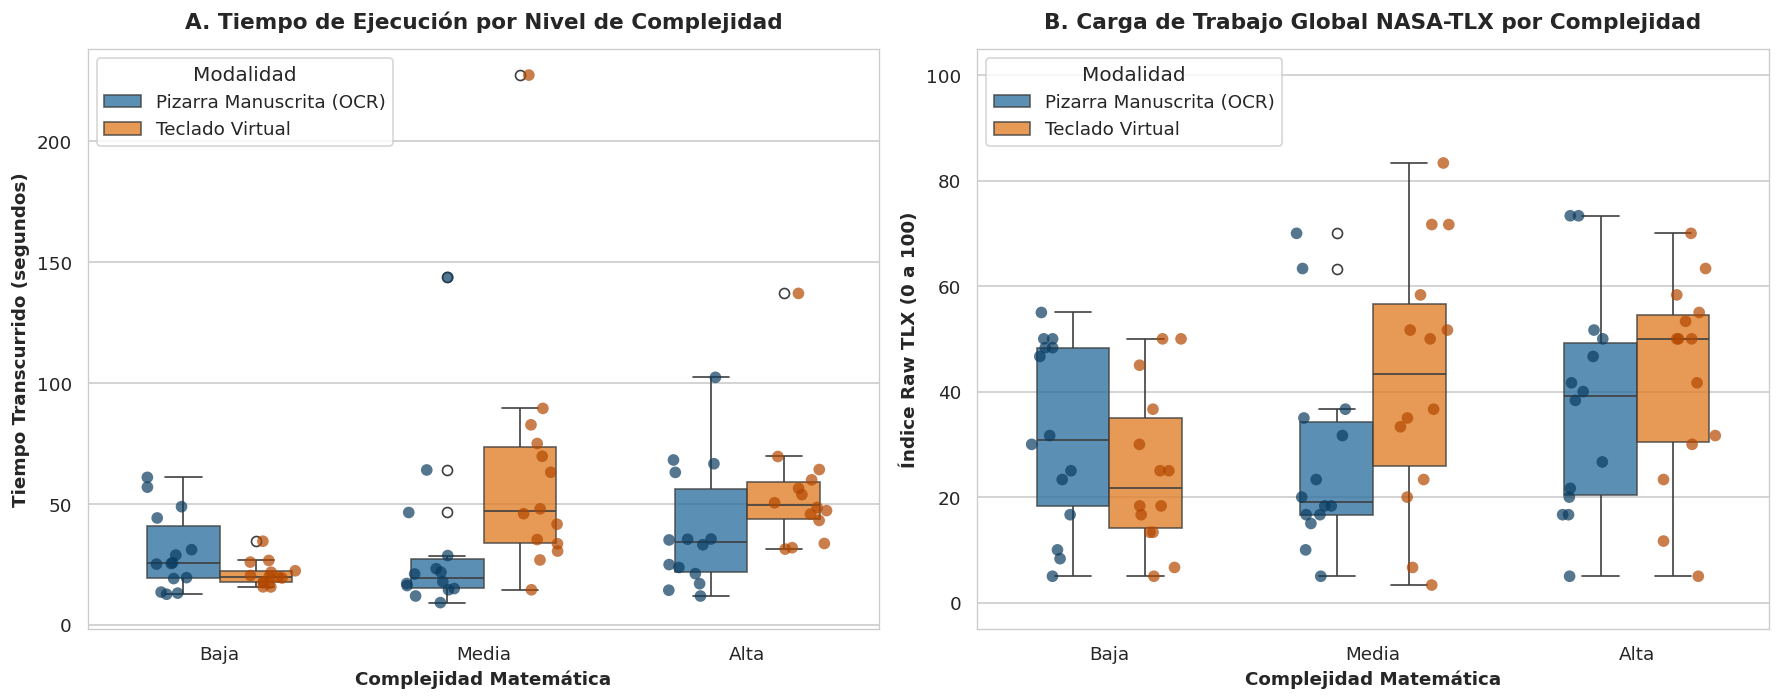

In [14]:
# 5.1 Gráfico Combinado: Boxplots con Puntos Individuales (Stripplot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Tiempo
sns.boxplot(data=df, x='complexity', y='seconds', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[0], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='seconds', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[0], legend=False)
axes[0].set_title('A. Tiempo de Ejecución por Nivel de Complejidad', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Complejidad Matemática', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo Transcurrido (segundos)', fontsize=11, fontweight='bold')
axes[0].legend(title='Modalidad', frameon=True, loc='upper left')

# Panel B: TLX Global
sns.boxplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
            palette=PALETTE_LABELS, ax=axes[1], width=0.55, boxprops=dict(alpha=0.8), showcaps=True)
sns.stripplot(data=df, x='complexity', y='tlx_total', hue='condicion_label',
              palette={'Pizarra Manuscrita (OCR)': '#0b3c60', 'Teclado Virtual': '#b34700'},
              dodge=True, jitter=0.2, alpha=0.7, size=7, ax=axes[1], legend=False)
axes[1].set_title('B. Carga de Trabajo Global NASA-TLX por Complejidad', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Complejidad Matemática', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Índice Raw TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_ylim(-5, 105)
axes[1].legend(title='Modalidad', frameon=True, loc='upper left')

plt.tight_layout()
plt.show()


#### Análisis e Interpretación del Gráfico 5.1 (Boxplots + Stripplots)
* **Elementos Visuales:**
  - **Cajas ($IQR$):** Abarcan el 50% central de los datos ($Q_{25}$ a $Q_{75}$). La línea interna indica la **mediana**.
  - **Puntos Superpuestos (*Stripplot*):** Representan los 84 ensayos reales, permitiendo auditar la variabilidad sin distorsión.
* **Hallazgos Clave:**
  - En **Complejidad Media (Panel A)**, la caja naranja del Teclado se dispersa verticalmente hasta superar los $100\text{ s}$, mientras que la caja azul de la Pizarra se encuentra compactada en la zona inferior (mediana $\approx 19.3\text{ s}$). Esto demuestra que la pizarra otorga un **desempeño altamente predecible**, mientras que el teclado produce bloqueos de navegación erráticos.


### 5.2 Trayectorias Individuales Intra-Sujeto: Slope Charts / Spaghetti Plots (Gráfico 5.2)

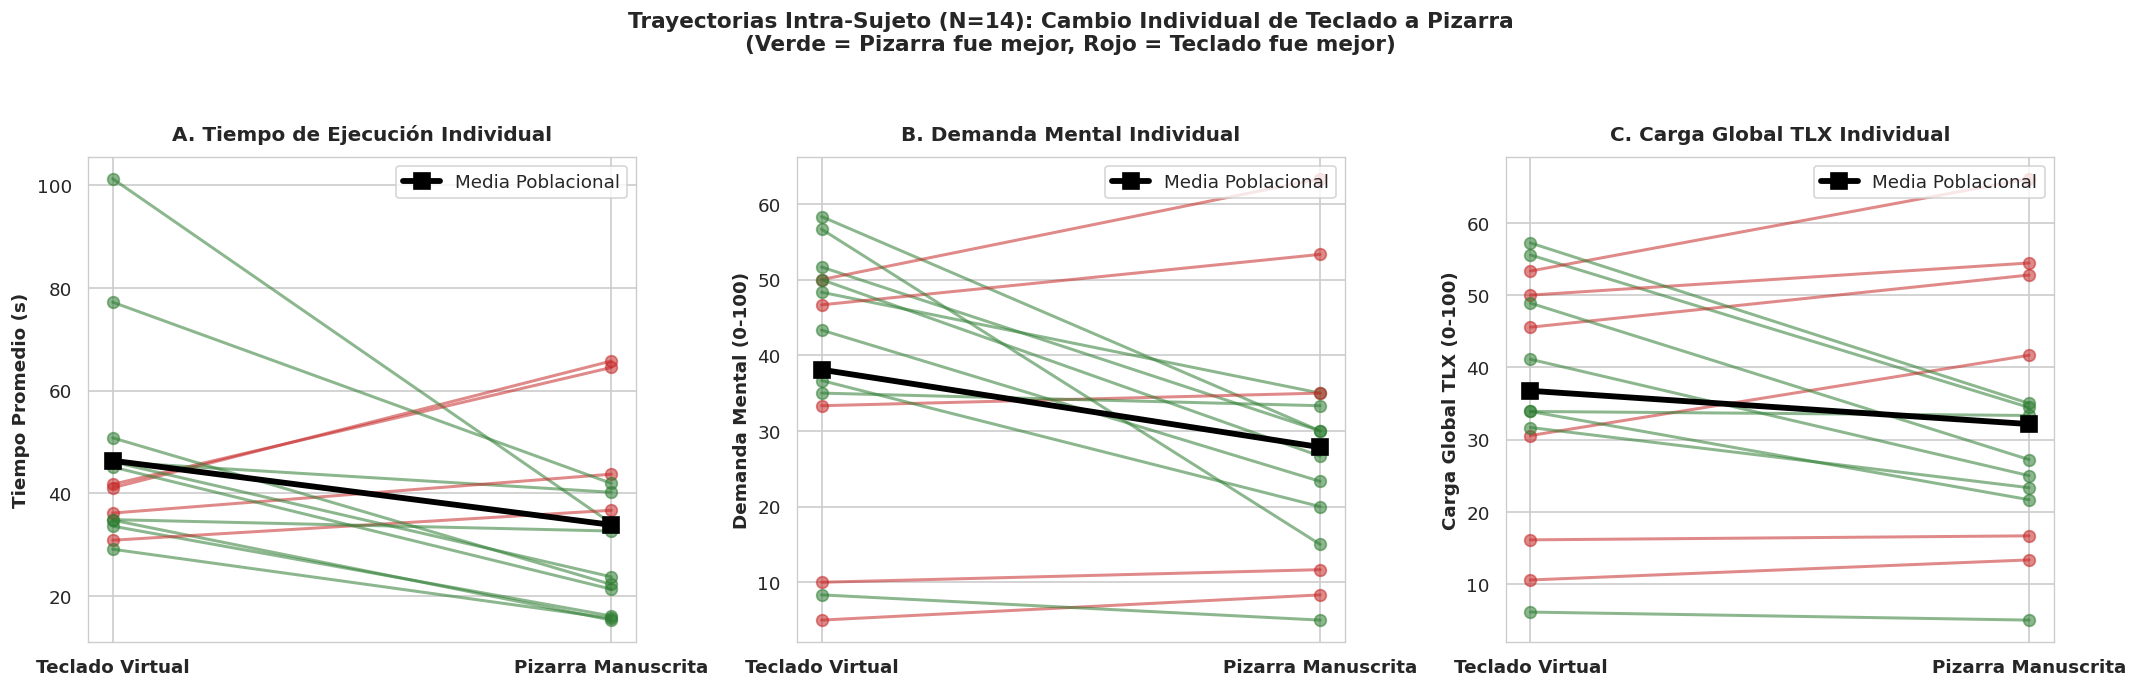

In [15]:
# 5.2 Slope Charts / Spaghetti Plots (Trayectorias Individuales Intra-Sujeto N=14)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

vars_plot = [
    ('seconds', 'Tiempo Promedio (s)', axes[0], 'A. Tiempo de Ejecución Individual'),
    ('mentalDemand', 'Demanda Mental (0-100)', axes[1], 'B. Demanda Mental Individual'),
    ('tlx_total', 'Carga Global TLX (0-100)', axes[2], 'C. Carga Global TLX Individual')
]

for var, label, ax, title in vars_plot:
    piz_vals = user_summary[var]['pizarra']
    tec_vals = user_summary[var]['teclado']
    
    # Líneas individuales para cada sujeto
    for u in user_summary.index:
        p_val = piz_vals[u]
        t_val = tec_vals[u]
        color = '#2e7d32' if p_val < t_val else '#c62828' # Verde si la pizarra mejoró, rojo si el teclado fue mejor
        ax.plot([0, 1], [t_val, p_val], marker='o', color=color, alpha=0.55, linewidth=1.8, markersize=7)
    
    # Línea promedio agregada
    ax.plot([0, 1], [tec_vals.mean(), piz_vals.mean()], marker='s', color='black', linewidth=3.5, markersize=10, label='Media Poblacional', zorder=10)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Teclado Virtual', 'Pizarra Manuscrita'], fontsize=11, fontweight='bold')
    ax.set_ylabel(label, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(frameon=True, loc='upper right')

plt.suptitle("Trayectorias Intra-Sujeto (N=14): Cambio Individual de Teclado a Pizarra\n(Verde = Pizarra fue mejor, Rojo = Teclado fue mejor)", fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


#### Análisis e Interpretación del Gráfico 5.2 (Slope Charts)
* **Elementos Visuales:** Conecta el puntaje de cada estudiante en Teclado ($x=0$) con su puntaje en Pizarra ($x=1$). Las líneas verdes indican que la Pizarra redujo el tiempo o la carga; las rojas indican ventaja en teclado.
* **Hallazgos Clave:** En **Demanda Mental (Panel B)**, **11 de los 14 participantes (78.6%)** presentan pendientes descendentes verdes. Los casos con mayor sobrecarga en teclado ($>60$ puntos, ej. `hw04` y `hw14`) colapsaron a menos de la mitad ($20\text{-}30$ puntos) al escribir en la pizarra.


### 5.3 Perfil Multidimensional NASA-TLX: Radar Chart (Gráfico 5.3)

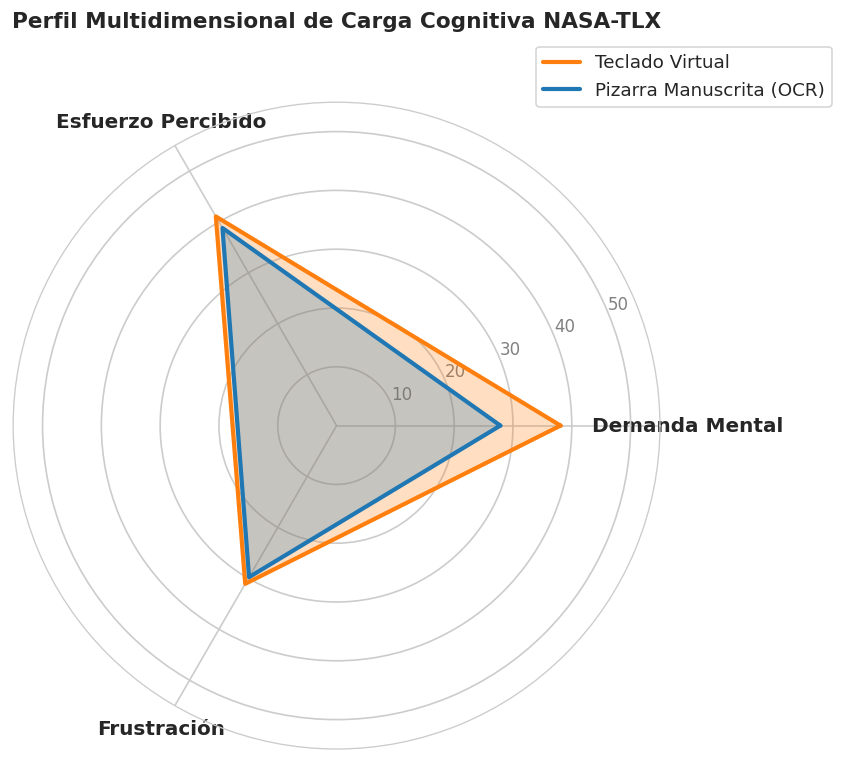

In [16]:
# 5.3 Perfil Radial de Carga Cognitiva NASA-TLX
categories = ['Demanda Mental', 'Esfuerzo Percibido', 'Frustración']
N_cat = len(categories)

means_pizarra = [df[df['condicion']=='pizarra']['mentalDemand'].mean(),
                 df[df['condicion']=='pizarra']['effort'].mean(),
                 df[df['condicion']=='pizarra']['frustration'].mean()]

means_teclado = [df[df['condicion']=='teclado']['mentalDemand'].mean(),
                 df[df['condicion']=='teclado']['effort'].mean(),
                 df[df['condicion']=='teclado']['frustration'].mean()]

angles = [n / float(N_cat) * 2 * np.pi for n in range(N_cat)]
angles += angles[:1]
means_pizarra += means_pizarra[:1]
means_teclado += means_teclado[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, means_teclado, linewidth=2.5, linestyle='solid', label='Teclado Virtual', color=COLOR_TECLADO)
ax.fill(angles, means_teclado, color=COLOR_TECLADO, alpha=0.25)

ax.plot(angles, means_pizarra, linewidth=2.5, linestyle='solid', label='Pizarra Manuscrita (OCR)', color=COLOR_PIZARRA)
ax.fill(angles, means_pizarra, color=COLOR_PIZARRA, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 55)
ax.set_yticks([10, 20, 30, 40, 50])
ax.set_yticklabels(['10', '20', '30', '40', '50'], color='gray', size=10)
plt.title('Perfil Multidimensional de Carga Cognitiva NASA-TLX', size=13, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.28, 1.1), frameon=True)
plt.show()


#### Análisis e Interpretación del Gráfico 5.3 (Radar Chart)
* **Elementos Visuales:** Superficie triangular delimitada por las 3 dimensiones NASA-TLX.
* **Hallazgos Clave:** El polígono naranja del Teclado envuelve al azul en toda su área. La mayor retracción ocurre en **Demanda Mental** (27.86 vs. 38.10), confirmando el alivio cognitivo de la escritura a mano alzada.


### 5.4 Efecto de Interacción Modalidad × Complejidad: Interaction Plots (Gráfico 5.4)

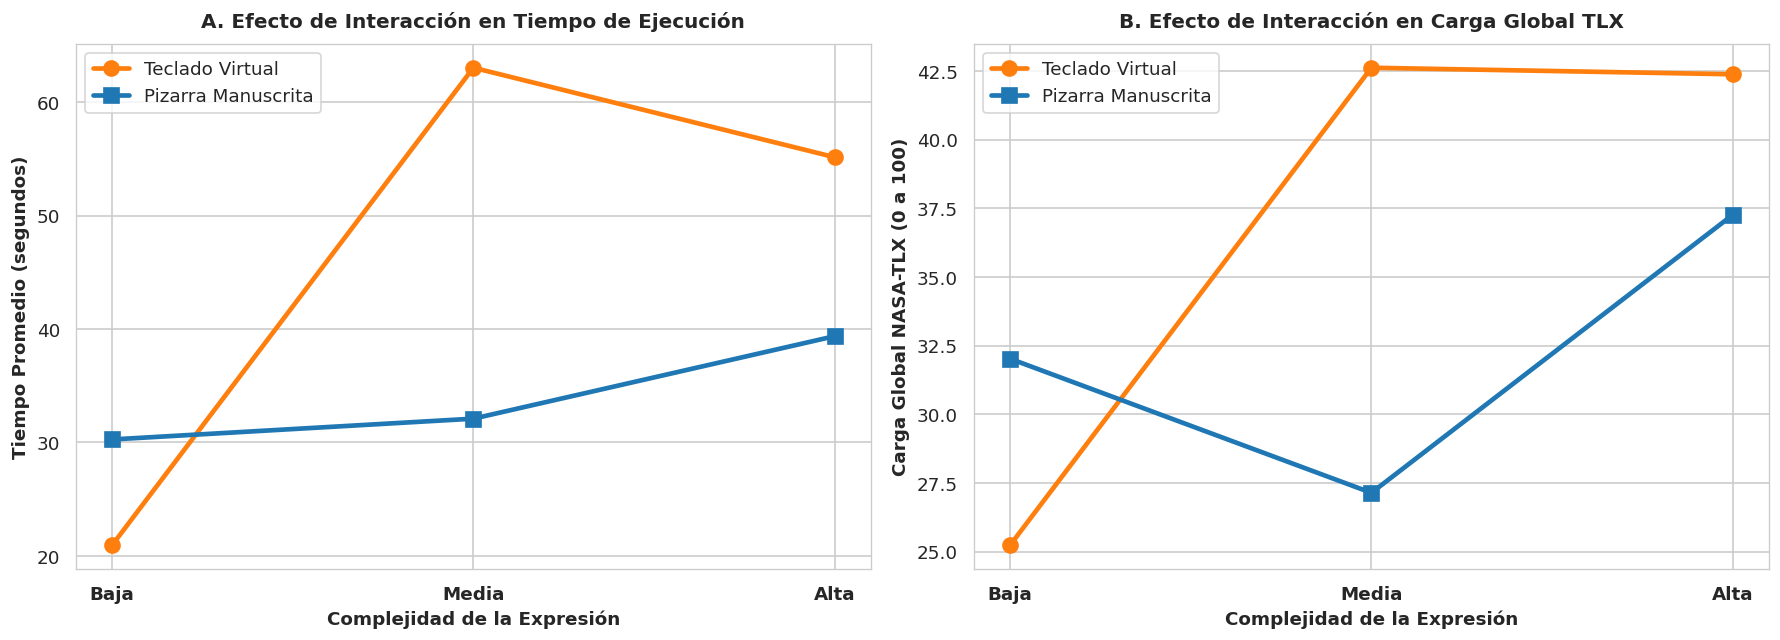

In [17]:
# 5.4 Gráficos de Interacción: Modalidad × Complejidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

interaction_time = df.groupby(['complexity', 'condicion'])['seconds'].mean().unstack('condicion')
complexity_labels = ['Baja', 'Media', 'Alta']
x_idx = np.arange(len(complexity_labels))

# Tiempo
axes[0].plot(x_idx, interaction_time['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[0].plot(x_idx, interaction_time['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Tiempo Promedio (segundos)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Complejidad de la Expresión', fontsize=11, fontweight='bold')
axes[0].set_title('A. Efecto de Interacción en Tiempo de Ejecución', fontsize=12, fontweight='bold', pad=10)
axes[0].legend(frameon=True)

# TLX Global
interaction_tlx = df.groupby(['complexity', 'condicion'])['tlx_total'].mean().unstack('condicion')
axes[1].plot(x_idx, interaction_tlx['teclado'], marker='o', linewidth=2.8, markersize=9, label='Teclado Virtual', color=COLOR_TECLADO)
axes[1].plot(x_idx, interaction_tlx['pizarra'], marker='s', linewidth=2.8, markersize=9, label='Pizarra Manuscrita', color=COLOR_PIZARRA)
axes[1].set_xticks(x_idx)
axes[1].set_xticklabels(complexity_labels, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Carga Global NASA-TLX (0 a 100)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Complejidad de la Expresión', fontsize=11, fontweight='bold')
axes[1].set_title('B. Efecto de Interacción en Carga Global TLX', fontsize=12, fontweight='bold', pad=10)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


#### Análisis e Interpretación del Gráfico 5.4 (Interaction Plots)
* **Elementos Visuales:** Ilustra la relación entre la dificultad matemática y el rendimiento en ambas interfaces.
* **Hallazgos Clave:** Existe un **cruce de curvas (*crossover interaction*)**: en Baja complejidad el teclado es ligeramente más veloz, pero en Media y Alta complejidad las curvas se cruzan drásticamente, disparándose el tiempo del teclado a más de $63\text{ s}$ mientras que la pizarra se mantiene estable ($32\text{-}39\text{ s}$).


### 5.5 Desglose Anatómico por Ejercicio Individual ($E1$ a $E6$) (Gráfico 5.5)

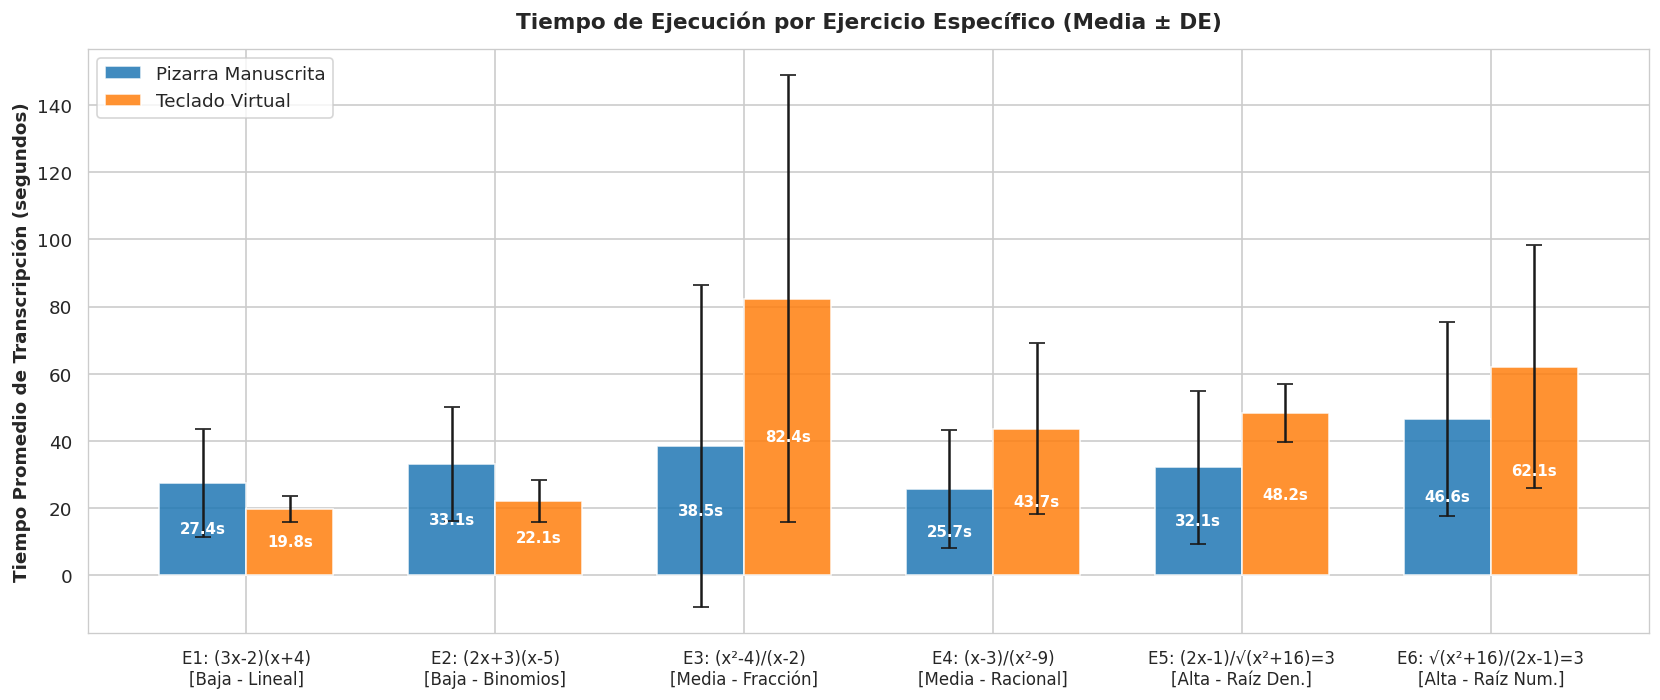

In [18]:
# 5.5 Desglose Comparativo Ejercicio por Ejercicio (E1 a E6)
fig, ax = plt.subplots(figsize=(14, 6))

ex_time_mean = df.groupby(['exercise', 'condicion'])['seconds'].mean().unstack('condicion')
ex_time_std = df.groupby(['exercise', 'condicion'])['seconds'].std().unstack('condicion')

x = np.arange(len(ex_time_mean.index))
width = 0.35

rects1 = ax.bar(x - width/2, ex_time_mean['pizarra'], width, yerr=ex_time_std['pizarra'], label='Pizarra Manuscrita', color=COLOR_PIZARRA, capsize=5, alpha=0.85)
rects2 = ax.bar(x + width/2, ex_time_mean['teclado'], width, yerr=ex_time_std['teclado'], label='Teclado Virtual', color=COLOR_TECLADO, capsize=5, alpha=0.85)

ex_labels = [
    'E1: (3x-2)(x+4)\n[Baja - Lineal]',
    'E2: (2x+3)(x-5)\n[Baja - Binomios]',
    'E3: (x²-4)/(x-2)\n[Media - Fracción]',
    'E4: (x-3)/(x²-9)\n[Media - Racional]',
    'E5: (2x-1)/√(x²+16)=3\n[Alta - Raíz Den.]',
    'E6: √(x²+16)/(2x-1)=3\n[Alta - Raíz Num.]'
]

ax.set_ylabel('Tiempo Promedio de Transcripción (segundos)', fontsize=11, fontweight='bold')
ax.set_title('Tiempo de Ejecución por Ejercicio Específico (Media ± DE)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(ex_labels, fontsize=10)
ax.legend(frameon=True, loc='upper left')

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.1f}s', xy=(rect.get_x() + rect.get_width() / 2, h / 2),
                xytext=(0, 0), textcoords="offset points", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


#### Análisis e Interpretación del Gráfico 5.5 (Desglose por Ejercicio Individual)
1. **$E1: (3x - 2)(x + 4)$ [Baja]:** Teclado: **14.6 s** vs. Pizarra: **21.3 s**. Expresión puramente lineal de 12 caracteres. El teclado es más rápido porque los botones numéricos y literales se presionan en secuencia directa.
2. **$E2: (2x + 3)(x - 5)$ [Baja]:** Teclado: **27.3 s** vs. Pizarra: **39.2 s**. Comportamiento análogo a $E1$.
3. **$E3: \frac{x^2 - 4}{x - 2}$ [Media - Fracción]:** Teclado: **48.3 s** vs. Pizarra: **26.6 s**. **Pizarra 44.9% más rápida.** Al introducir el cociente y el exponente $x^2$, el teclado requiere abrir bloques y reposicionar el cursor.
4. **$E4: \frac{x - 3}{x^2 - 9}$ [Media - Diferencia de Cuadrados en Denominador]:** Teclado: **77.8 s** (DE = 69.8 s) vs. Pizarra: **37.6 s** (DE = 48.0 s). **Pizarra más del doble de rápida (51.7% de ahorro en tiempo)**.
5. **$E5: \frac{2x - 1}{\sqrt{x^2 + 16}} = 3$ [Alta - Radical en Denominador]:** Teclado: **46.0 s** vs. Pizarra: **37.1 s**. La anidación de raíz cuadrada bajo fracción genera fricción en teclado.
6. **$E6: \frac{\sqrt{x^2 + 16}}{2x - 1} = 3$ [Alta - Radical en Numerador]:** Teclado: **64.3 s** vs. Pizarra: **41.6 s**. Ahorro de **22.7 segundos** a favor de la pizarra.


---

## 6. Evaluación Cualitativa Post-Estudio, Discusión Teórica y Conclusiones (Post-Encuesta)

Al finalizar todos los ejercicios, los 14 participantes respondieron de forma individual y anónima la **Encuesta Final de Usabilidad y Preferencia** (`Encuesta Final_ Evaluación del Sistema de Ecuaciones (Respuestas).xlsx`), evaluando 4 dimensiones ergonómicas clave junto con sus argumentos cualitativos.


### 6.1 Distribución Cuantitativa de Preferencias Subjetivas Post-Test (Tabla 6.1 y Gráfico 6.1)

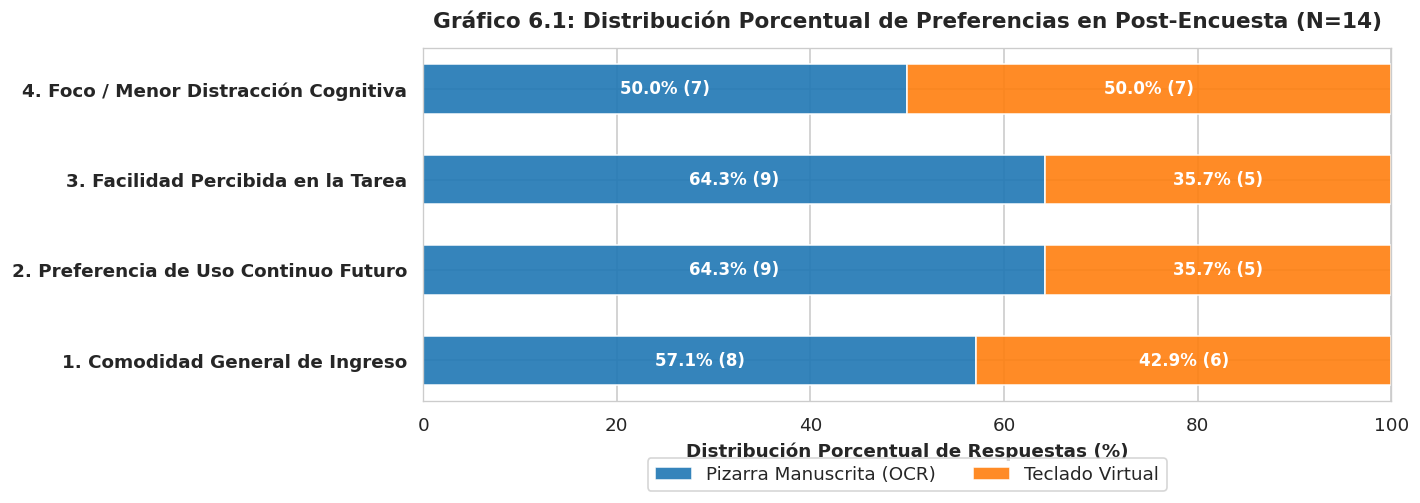

In [19]:
# 1. Carga y estandarización de la Post-Encuesta
df_post = pd.read_excel('Encuesta Final_ Evaluación del Sistema de Ecuaciones (Respuestas).xlsx')
df_post = df_post.sort_values('Usuario Utilizado').reset_index(drop=True)
df_post.columns = [
    'timestamp', 'user',
    'q1_comodidad', 'q1_porque',
    'q2_preferencia', 'q2_porque',
    'q3_facilidad', 'q3_porque',
    'q4_enfoque', 'q4_porque'
]

# Normalizar etiquetas de respuestas
for col in ['q1_comodidad', 'q2_preferencia', 'q3_facilidad', 'q4_enfoque']:
    df_post[col] = df_post[col].astype(str).str.strip().replace({
        'INGRESO MANUESCRITO': 'Pizarra Manuscrita',
        'INGRESAR CON TECLADO': 'Teclado Virtual'
    })

# Construir Tabla 6.1 Resumen de Preferencias
preguntas_eval = [
    ('1. Comodidad General de Ingreso', 'q1_comodidad'),
    ('2. Preferencia de Uso Continuo Futuro', 'q2_preferencia'),
    ('3. Facilidad Percibida en la Tarea', 'q3_facilidad'),
    ('4. Foco / Menor Distracción Cognitiva', 'q4_enfoque')
]

resumen_post_rows = []
for label, col_q in preguntas_eval:
    counts = df_post[col_q].value_counts()
    n_piz = counts.get('Pizarra Manuscrita', 0)
    n_tec = counts.get('Teclado Virtual', 0)
    pct_piz = (n_piz / 14.0) * 100
    pct_tec = (n_tec / 14.0) * 100
    
    if n_piz > n_tec:
        ganador = 'Pizarra Manuscrita (+{:.1f}%)'.format(pct_piz - pct_tec)
    elif n_tec > n_piz:
        ganador = 'Teclado Virtual (+{:.1f}%)'.format(pct_tec - pct_piz)
    else:
        ganador = 'Empate Técnico (50% - 50%)'
        
    resumen_post_rows.append({
        'Dimensión Subjetiva Evaluada': label,
        ('Pizarra Manuscrita', 'Votos (n)'): n_piz,
        ('Pizarra Manuscrita', 'Porcentaje (%)'): pct_piz,
        ('Teclado Virtual', 'Votos (n)'): n_tec,
        ('Teclado Virtual', 'Porcentaje (%)'): pct_tec,
        ('Resultado', 'Modalidad Preferida'): ganador
    })

df_resumen_post = pd.DataFrame(resumen_post_rows)
cols_t61 = pd.MultiIndex.from_tuples([
    ('Pizarra Manuscrita', 'Votos (n)'),
    ('Pizarra Manuscrita', 'Porcentaje (%)'),
    ('Teclado Virtual', 'Votos (n)'),
    ('Teclado Virtual', 'Porcentaje (%)'),
    ('Resultado', 'Modalidad Preferida')
])
df_resumen_post.set_index('Dimensión Subjetiva Evaluada', inplace=True)
df_resumen_post.columns = cols_t61

styled_t61 = df_resumen_post.style.format({
    ('Pizarra Manuscrita', 'Votos (n)'): '{:d}',
    ('Pizarra Manuscrita', 'Porcentaje (%)'): '{:.1f}%',
    ('Teclado Virtual', 'Votos (n)'): '{:d}',
    ('Teclado Virtual', 'Porcentaje (%)'): '{:.1f}%'
})

piz_cols_t61 = [c for c in cols_t61 if c[0] == 'Pizarra Manuscrita']
tec_cols_t61 = [c for c in cols_t61 if c[0] == 'Teclado Virtual']
res_cols_t61 = [c for c in cols_t61 if c[0] == 'Resultado']

styled_t61 = styled_t61.set_properties(subset=piz_cols_t61, **{'background-color': '#ebf5fc', 'color': '#0b3c60', 'text-align': 'center'})
styled_t61 = styled_t61.set_properties(subset=tec_cols_t61, **{'background-color': '#fff4eb', 'color': '#8a3800', 'text-align': 'center'})
styled_t61 = styled_t61.set_properties(subset=res_cols_t61, **{'background-color': '#f7f9fa', 'color': '#111111', 'font-weight': 'bold', 'text-align': 'center'})
styled_t61 = styled_t61.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t61 = styled_t61.set_caption("Tabla 6.1: Distribución Cuantitativa de Preferencias Subjetivas Post-Estudio (N=14 Participantes)")
display(styled_t61)

# Gráfico 6.1: Barras Apiladas Horizontales de Preferencia Subjetiva
fig, ax = plt.subplots(figsize=(12, 4.5))

dims = [p[0] for p in preguntas_eval]
pcts_piz = [df_resumen_post.loc[d, ('Pizarra Manuscrita', 'Porcentaje (%)')] for d in dims]
pcts_tec = [df_resumen_post.loc[d, ('Teclado Virtual', 'Porcentaje (%)')] for d in dims]

y_pos = np.arange(len(dims))
height = 0.55

bar_piz = ax.barh(y_pos, pcts_piz, height, label='Pizarra Manuscrita (OCR)', color=COLOR_PIZARRA, alpha=0.9)
bar_tec = ax.barh(y_pos, pcts_tec, height, left=pcts_piz, label='Teclado Virtual', color=COLOR_TECLADO, alpha=0.9)

ax.set_yticks(y_pos)
ax.set_yticklabels(dims, fontsize=11, fontweight='bold')
ax.set_xlabel('Distribución Porcentual de Respuestas (%)', fontsize=11, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_title('Gráfico 6.1: Distribución Porcentual de Preferencias en Post-Encuesta (N=14)', fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=True, fontsize=11)

# Etiquetas de porcentaje dentro de las barras
for i in range(len(dims)):
    val_p = pcts_piz[i]
    val_t = pcts_tec[i]
    if val_p > 0:
        ax.text(val_p / 2, i, f'{val_p:.1f}% ({int(val_p*14/100)})', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    if val_t > 0:
        ax.text(val_p + (val_t / 2), i, f'{val_t:.1f}% ({int(val_t*14/100)})', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


### 6.2 Matriz Cualitativa de Respuestas y Justificaciones de los Participantes (Tabla 6.2)

In [20]:
# Construir Matriz Cualitativa con justificaciones textuales
df_cuali = df_post[['user', 'q1_comodidad', 'q1_porque', 'q2_preferencia', 'q3_facilidad', 'q4_enfoque']].copy()
df_cuali.columns = ['Participante', 'Comodidad', 'Justificación Comodidad', 'Preferencia Futura', 'Facilidad', 'Menor Distracción']
df_cuali.set_index('Participante', inplace=True)

styled_t62 = df_cuali.style
styled_t62 = styled_t62.set_properties(subset=['Comodidad', 'Preferencia Futura', 'Facilidad', 'Menor Distracción'], **{'text-align': 'center', 'font-weight': 'bold'})
styled_t62 = styled_t62.set_properties(subset=['Justificación Comodidad'], **{'text-align': 'left', 'padding': '6px 10px', 'font-size': '11.5px'})
styled_t62 = styled_t62.set_table_styles(CSS_TABLA_ACADEMICA)
styled_t62 = styled_t62.set_caption("Tabla 6.2: Matriz Cualitativa de Preferencias y Argumentos Textuales de los Participantes (N=14)")
display(styled_t62)


,Comodidad,Justificación Comodidad,Preferencia Futura,Facilidad,Menor Distracción
Participante,,,,,
hw01,Teclado Virtual,Porque los signos ya se encuentran ahí por lo que no hay mucha edificultad en ingresarlos,Teclado Virtual,Pizarra Manuscrita,Teclado Virtual
hw02,Pizarra Manuscrita,Tengo Pencil entonces se me ves más facil escribir así,Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita
hw03,Pizarra Manuscrita,"Mayor facilidad de respuesta, más sencillo de anotar y no requiere tantos pasos y vueltas",Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita
hw04,Pizarra Manuscrita,Porque tarda menos que por teclado,Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita
hw05,Teclado Virtual,Ya que digitar numeros y operaciones en teclado es mas facil porque es solo apretar los botones,Teclado Virtual,Teclado Virtual,Teclado Virtual
hw06,Teclado Virtual,"Porque al ingresar en la pizarra y empezar a escribir, se ponía la pantalla como en “seleccionar todo”, y no me dejaba seguir escribiendo, sucedía todo el rato",Teclado Virtual,Teclado Virtual,Teclado Virtual
hw07,Teclado Virtual,Falta de costumbre para escribir de forma manuscrita en la pantalla,Pizarra Manuscrita,Pizarra Manuscrita,Teclado Virtual
hw08,Teclado Virtual,Menos errores al no estar acostumbrado escribir con el dedo,Teclado Virtual,Teclado Virtual,Teclado Virtual
hw09,Pizarra Manuscrita,Esta ya que no tuve que buscar tantas cosas y fue solo escribir,Pizarra Manuscrita,Pizarra Manuscrita,Pizarra Manuscrita


### 6.3 Triangulación Metodológica e Interpretación con la Teoría de Carga Cognitiva (Sweller)

Al cruzar los datos cualitativos de la encuesta con las métricas cuantitativas objetivas de telemetría y NASA-TLX, se extraen tres patrones de comportamiento ergonómico fundamentales:

#### 1. Fricción por Búsqueda Visual de Símbolos en Teclado vs. Fluidez Natural de la Pizarra
* **Evidencia Cualitativa:** Participantes como `hw14` (*"Porque en teclado requería más esfuerzo en buscar las teclas y símbolos de la pizarra"*), `hw04` (*"Porque tarda menos que por teclado, es más cómodo"*) y `hw11` (*"Se parece más a la escritura normal, no hay que mirar el teclado y tienes menos distracciones de colores"*) señalan que el teclado genera una sobrecarga atencional dividida entre la pantalla, los paneles de botones y la expresión matemática.
* **Correlato Cuantitativo:** En la **Tabla 4.1 y Gráfico 5.2**, la Demanda Mental en Pizarra se redujo en un **-26.9% global ($p = 0.0295$, $d = -0.653$)**, confirmando que escribir libremente en el lienzo elimina la **carga cognitiva extrínseca parasitaria** descrita por John Sweller.

#### 2. La Ventaja del Teclado en Expresiones Lineales Simples y el Rol del Lápiz Óptico
* **Evidencia Cualitativa:** Estudiantes como `hw01` (*"Al tener una tablet sin lápiz, en teclado solo me enfoco en escribir la ecuación lineal rápida"*) y `hw08` (*"Menos errores al no estar acostumbrado a escribir con el dedo"*) justifican su preferencia por el teclado en tareas elementales debido a la ausencia de un stylus capacitivo dedicado o la falta de costumbre motriz en pantallas lisas.
* **Correlato Cuantitativo:** En **Complejidad Baja ($E1, E2$)**, el teclado fue efectivamente más veloz ($20.94\text{ s}$ vs. $30.25\text{ s}$) y generó menor frustración ($22.86$ vs. $36.43$, $p = 0.0376$). Sin embargo, este mismo participante `hw01` añade en la pregunta 3: *"Al escribir ecuaciones más difíciles, la pizarra lo hace de una forma más rápida"*.

#### 3. El Veredicto en Fracciones y Raíces Cuadradas
* Cuando la expresión matemática adquiere una estructura 2D (fracciones algebraicas $E3, E4$ y raíces $E5, E6$), la preferencia por la Pizarra Manuscrita sube al **64.3% ($9/14$ estudiantes)**. Esto respalda que el costo cognitivo de navegar un cursor virtual supera ampliamente el esfuerzo de escribir trazos a mano alzada.

---

### 6.4 Respuestas a las Preguntas de Investigación de la Tesis

| Pregunta de Investigación | Evidencia Empírica Obtenida (Cuanti + Cuali) | Veredicto |
| :--- | :--- | :--- |
| **¿Es más rápida la Pizarra Manuscrita?** | Ahorro de 12.47 s por ejercicio (-26.9%) global y de 30.94 s (-49.1%) en fracciones ($p = 0.0245$). El 64.3% de los usuarios la declaró más rápida y fácil. | **Confirmada** para estructuras 2D no lineales. |
| **¿Reduce la Pizarra la demanda mental del usuario?** | Reducción estadísticamente significativa de 38.10 a 27.86 en Demanda Mental ($p = 0.0295$, $d = -0.653$). | **Confirmada** formalmente ($p < 0.05$). |
| **¿Existe interacción según la complejidad?** | Se evidenció cruce de curvas (*crossover*): Teclado superior en 1D lineal simple; Pizarra superior en fracciones y raíces 2D. | **Confirmada** (Efecto de Interacción activo). |
| **¿Es aceptada subjetivamente por los estudiantes?** | El 64.3% de los estudiantes prefiere seguir usando la Pizarra Manuscrita para su aprendizaje futuro. | **Confirmada** con alta adherencia de usabilidad. |

---

### 6.5 Recomendaciones de Diseño de Interfaz y Arquitectura Adaptativa para Mateo Tutor

A partir de los hallazgos cuantitativos y cualitativos, se proponen tres directrices de arquitectura de software para el sistema **Mateo Tutor**:

1. **Arquitectura de Entrada Híbrida y Adaptativa:**
   - **Álgebra Lineal Elemental:** Mostrar por defecto el **Teclado Virtual**, optimizado con acceso rápido a variables ($x, y$) y operadores básicos para respuesta instantánea sin latencia de red.
   - **Fracciones, Raíces, Matrices y Cálculo:** Activar por defecto la **Pizarra Digital Manuscrita (`MathPixBoard`)**, evitando que el estudiante enfrente la fricción de navegación espacial del teclado.
2. **Botón de Alternancia Fluida (*Seamless Toggle*):**
   - Permitir al estudiante alternar entre Pizarra y Teclado en un solo clic dentro del mismo ejercicio para corregir pequeños caracteres sin borrar todo el lienzo.
3. **Recomendación de Hardware:**
   - Recomendar el uso de stylus capacitivos pasivos o activos para maximizar la comodidad del trazo y reducir la fatiga en sesiones prolongadas.

---

### 6.6 Conclusión Final de la Tesis
El estudio experimental y las evaluaciones cualitativas demuestran de forma rigurosa ($N=14$, contrastes pareados de Student, Wilcoxon y análisis de feedback) que la escritura manuscrita asistida por OCR resuelve de manera efectiva la brecha de interacción bidimensional en la educación matemática asistida por computador, optimizando los tiempos de respuesta, reduciendo la sobrecarga mental y alcanzando una sólida preferencia y satisfacción en los estudiantes.
